# Getting started with calibrated-explanations - using the WrapCalibratedExplainer class
Author: Tuwe Löfström (tuwe.lofstrom@ju.se)  
Copyright 2023 Tuwe Löfström  
License: BSD 3 clause
## Classification
Let us illustrate how we may use `calibrated_explanations` to generate explanations from a classifier trained on a dataset from
[www.openml.org](https://www.openml.org), which we first split into a
training and a test set using `train_test_split` from
[sklearn](https://scikit-learn.org), and then further split the
training set into a proper training set and a calibration set:

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import ssl
import warnings

warnings.filterwarnings("ignore", category=UserWarning)


import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

if hasattr(ssl, "_create_unverified_context"):
    ssl._create_default_https_context = ssl._create_unverified_context

dataset = fetch_openml(name="mammography", version=1, as_frame=True, parser="auto")

X = dataset.data.values.astype(float)
y = (dataset.target.values == "1").astype(int)

feature_names = dataset.feature_names

i_test = np.array([np.arange(len(y))[y == 0][:4], np.arange(len(y))[y == 1][:4]]).reshape(-1)
i_train = np.setdiff1d(np.arange(len(y)), i_test)
x_train, y_train = X[i_train, :], y[i_train]
x_test, y_test = X[i_test, :], y[i_test]

X_prop_train, x_cal, y_prop_train, y_cal = train_test_split(
    x_train, y_train, test_size=0.25, stratify=y_train
)
display(y_test)

array([0, 0, 0, 0, 1, 1, 1, 1])

Before training, calibrating, predicting or explaining any instances, let us first look at the class distribution in the data set, to how imbalanced it is. 

In [3]:
print(f"number count of classes: {np.array(dataset.target.value_counts())}")
print(f"fraction of positive instances: {np.min(dataset.target.value_counts())/len(y)}")

number count of classes: [10923   260]
fraction of positive instances: 0.023249575248144506


We now create our wrapper object, using a `RandomForestClassifier` as learner. 

In [4]:
from sklearn.ensemble import RandomForestClassifier

from calibrated_explanations import WrapCalibratedExplainer, __version__

print(f"calibrated_explanations {__version__}")

classifier = WrapCalibratedExplainer(RandomForestClassifier())
display(classifier)

calibrated_explanations 0.11.3


WrapCalibratedExplainer(learner=RandomForestClassifier(), fitted=False, calibrated=False)

We now fit our model using the proper training set.

In [5]:
classifier.fit(X_prop_train, y_prop_train)
display(classifier)

WrapCalibratedExplainer(learner=RandomForestClassifier(), fitted=True, calibrated=False)

The `WrapCalibratedExplainer` class has a `predict` and a `predict_proba` method that returns the predictions and probability estimates of the underlying classifier. If the model is not yet calibrated, then the underlying models `predict` and `predict_proba` methods are used. If the model is calibrated, then the `predict` and `predict_proba` method of the calibration model is used.

In [6]:
print(f"Uncalibrated probability estimates: \n{classifier.predict_proba(x_test)}")

Uncalibrated probability estimates: 
[[1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [1.   0.  ]
 [0.99 0.01]
 [0.59 0.41]
 [0.09 0.91]
 [0.5  0.5 ]]


C:\Users\loftuw\AppData\Local\Temp\ipykernel_11272\56682136.py:1: UserWarning: The WrapCalibratedExplainer must be calibrated to get calibrated probabilities.
  print(f"Uncalibrated probability estimates: \n{classifier.predict_proba(x_test)}")


Before we can generate explanations, we need to calibrate our model using the calibration set. No discretizer is yet assigned.

In [7]:
classifier.calibrate(x_cal, y_cal, feature_names=feature_names)
display(classifier)

WrapCalibratedExplainer(learner=RandomForestClassifier(), fitted=True, calibrated=True, 
		explainer=CalibratedExplainer(mode=classification, learner=RandomForestClassifier()))

Once the model is calibrated, the `predict` and `predict_proba` methods produce calibrated predictions and probability estimates.

In [8]:
proba, (low, high) = classifier.predict_proba(x_test, uq_interval=True)
print(f"Calibrated probability estimates: \n{proba}")
print("Calibrated uncertainty interval for the positive class:")
print([(low[i], high[i]) for i in range(len(low))], end="\n")

Calibrated probability estimates: 
[[0.99753492 0.00246508]
 [0.99753492 0.00246508]
 [0.99753492 0.00246508]
 [0.99753492 0.00246508]
 [0.99466996 0.00533004]
 [0.42857143 0.57142857]
 [0.11111111 0.88888889]
 [0.42857143 0.57142857]]
Calibrated uncertainty interval for the positive class:
[(np.float64(0.002055076037813399), np.float64(0.002466091245376079)), (np.float64(0.002055076037813399), np.float64(0.002466091245376079)), (np.float64(0.002055076037813399), np.float64(0.002466091245376079)), (np.float64(0.002055076037813399), np.float64(0.002466091245376079)), (np.float64(0.002055076037813399), np.float64(0.0053475935828877)), (np.float64(0.55), np.float64(0.6)), (np.float64(0.875), np.float64(1.0)), (np.float64(0.55), np.float64(0.6))]


#### Factual Explanations
Let us explain a test instance using our `WrapCalibratedExplainer` object. The method used to get factual explanations is `explain_factual`. Note that the discretizer is now assigned.

In [9]:
factual_explanations = classifier.explain_factual(x_test)
display(classifier)

WrapCalibratedExplainer(learner=RandomForestClassifier(), fitted=True, calibrated=True, 
		explainer=CalibratedExplainer(mode=classification, discretizer=BinaryEntropyDiscretizer(), learner=RandomForestClassifier()))

Once we have the explanations, we can plot all of them using `plot`. Default, a regular plot, without uncertainty intervals included, is created. To include uncertainty intervals, change the parameter `uncertainty=True`. To plot only a single instance, the `plot` function can be called, submitting the index of the test instance to plot.

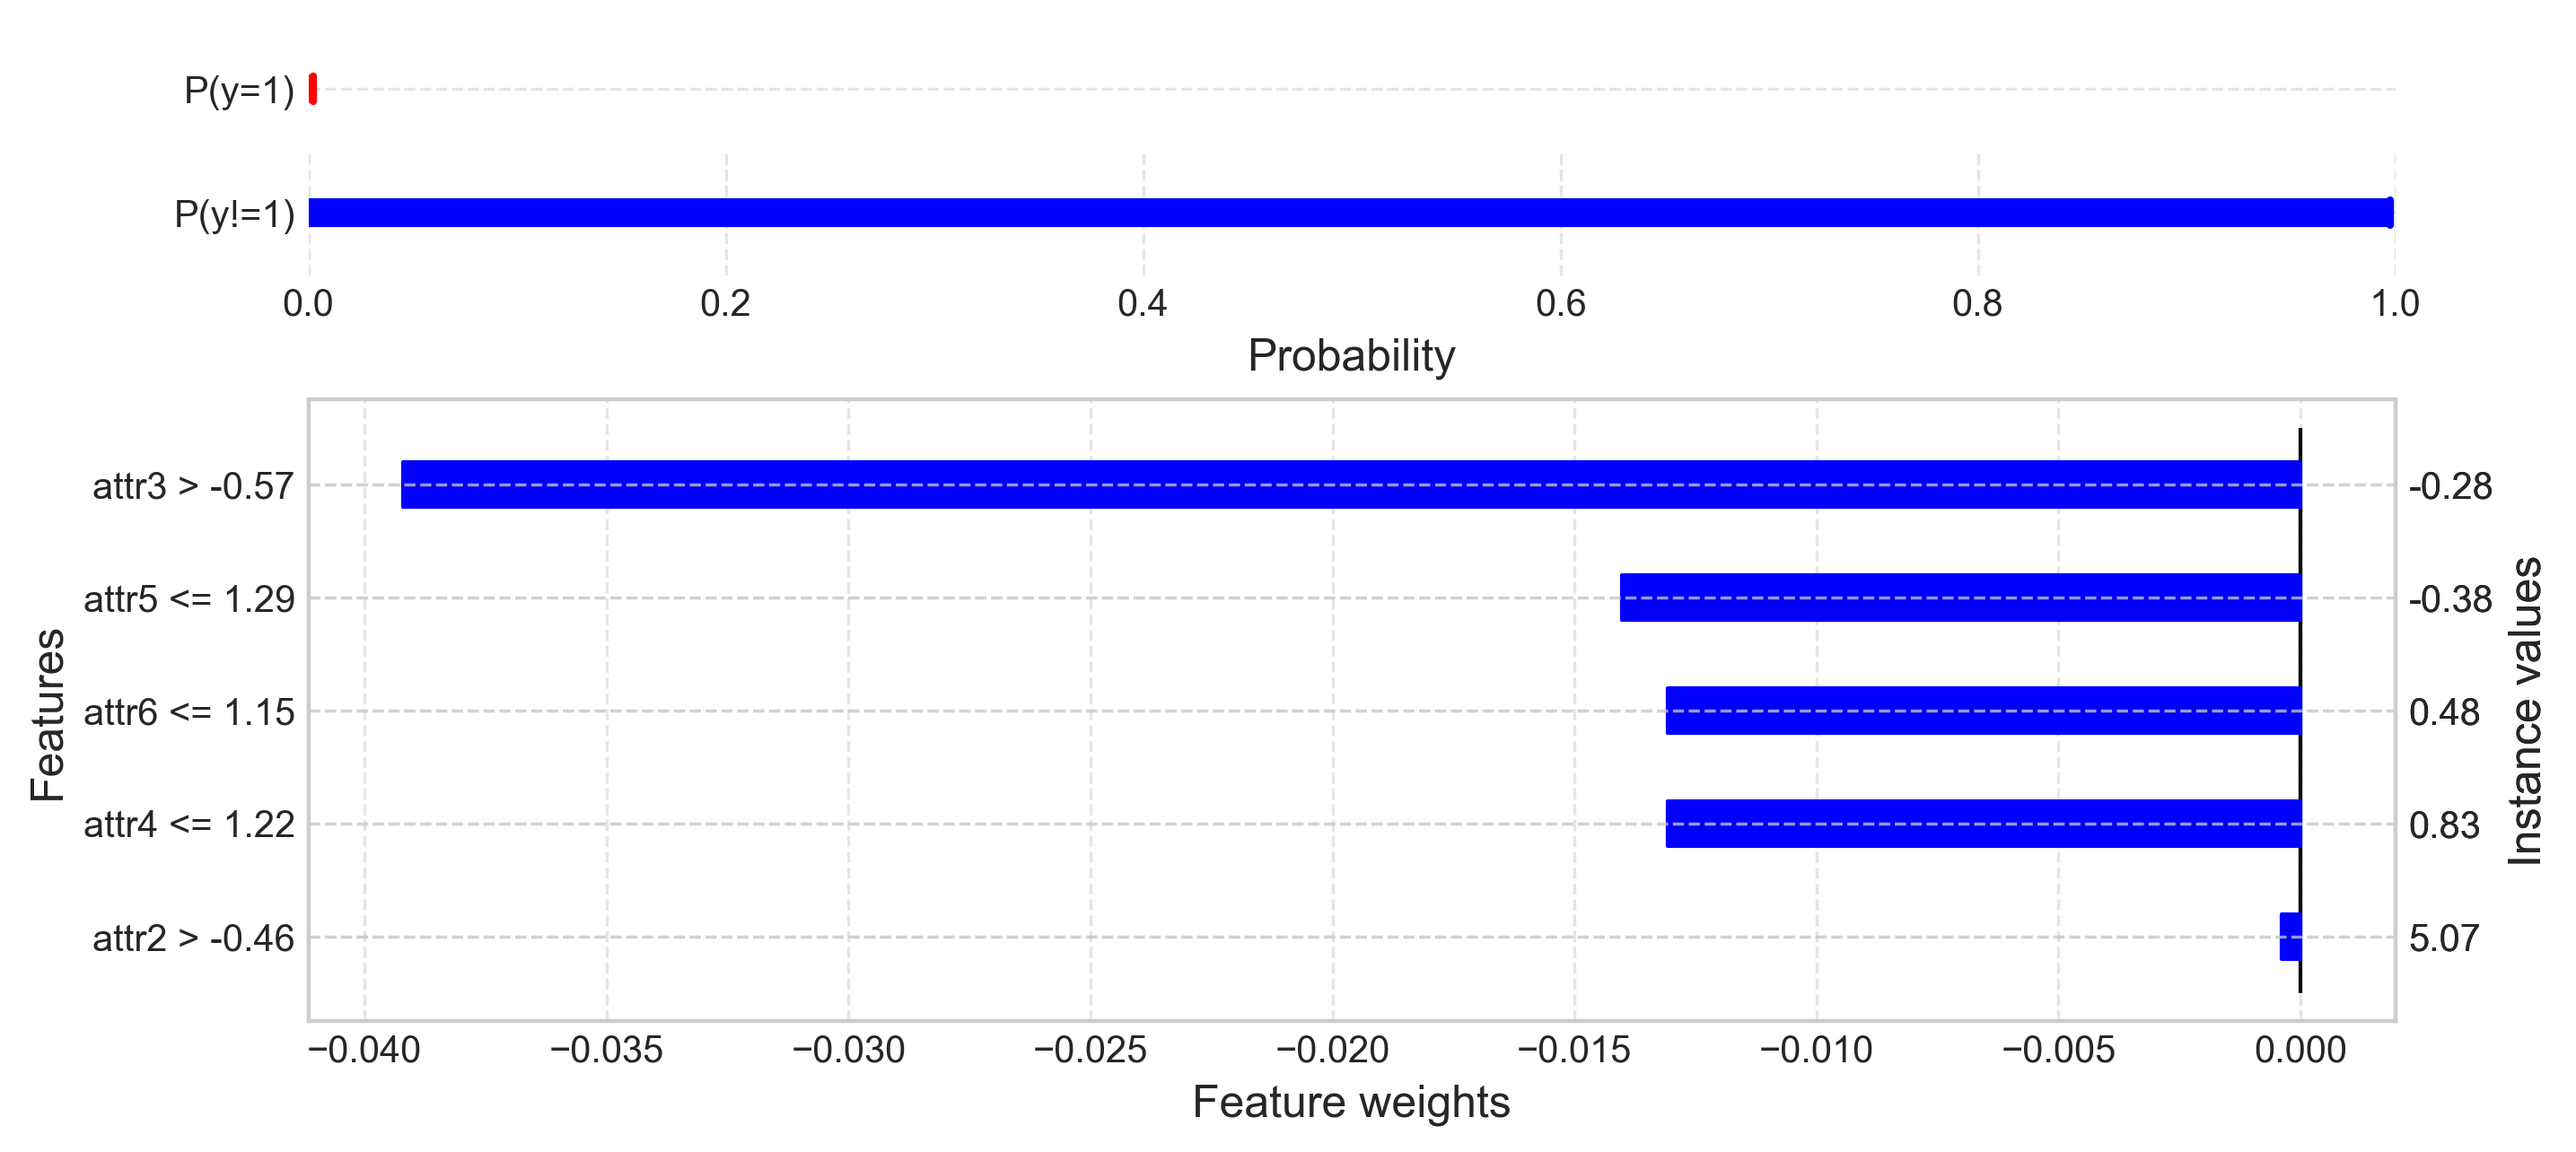

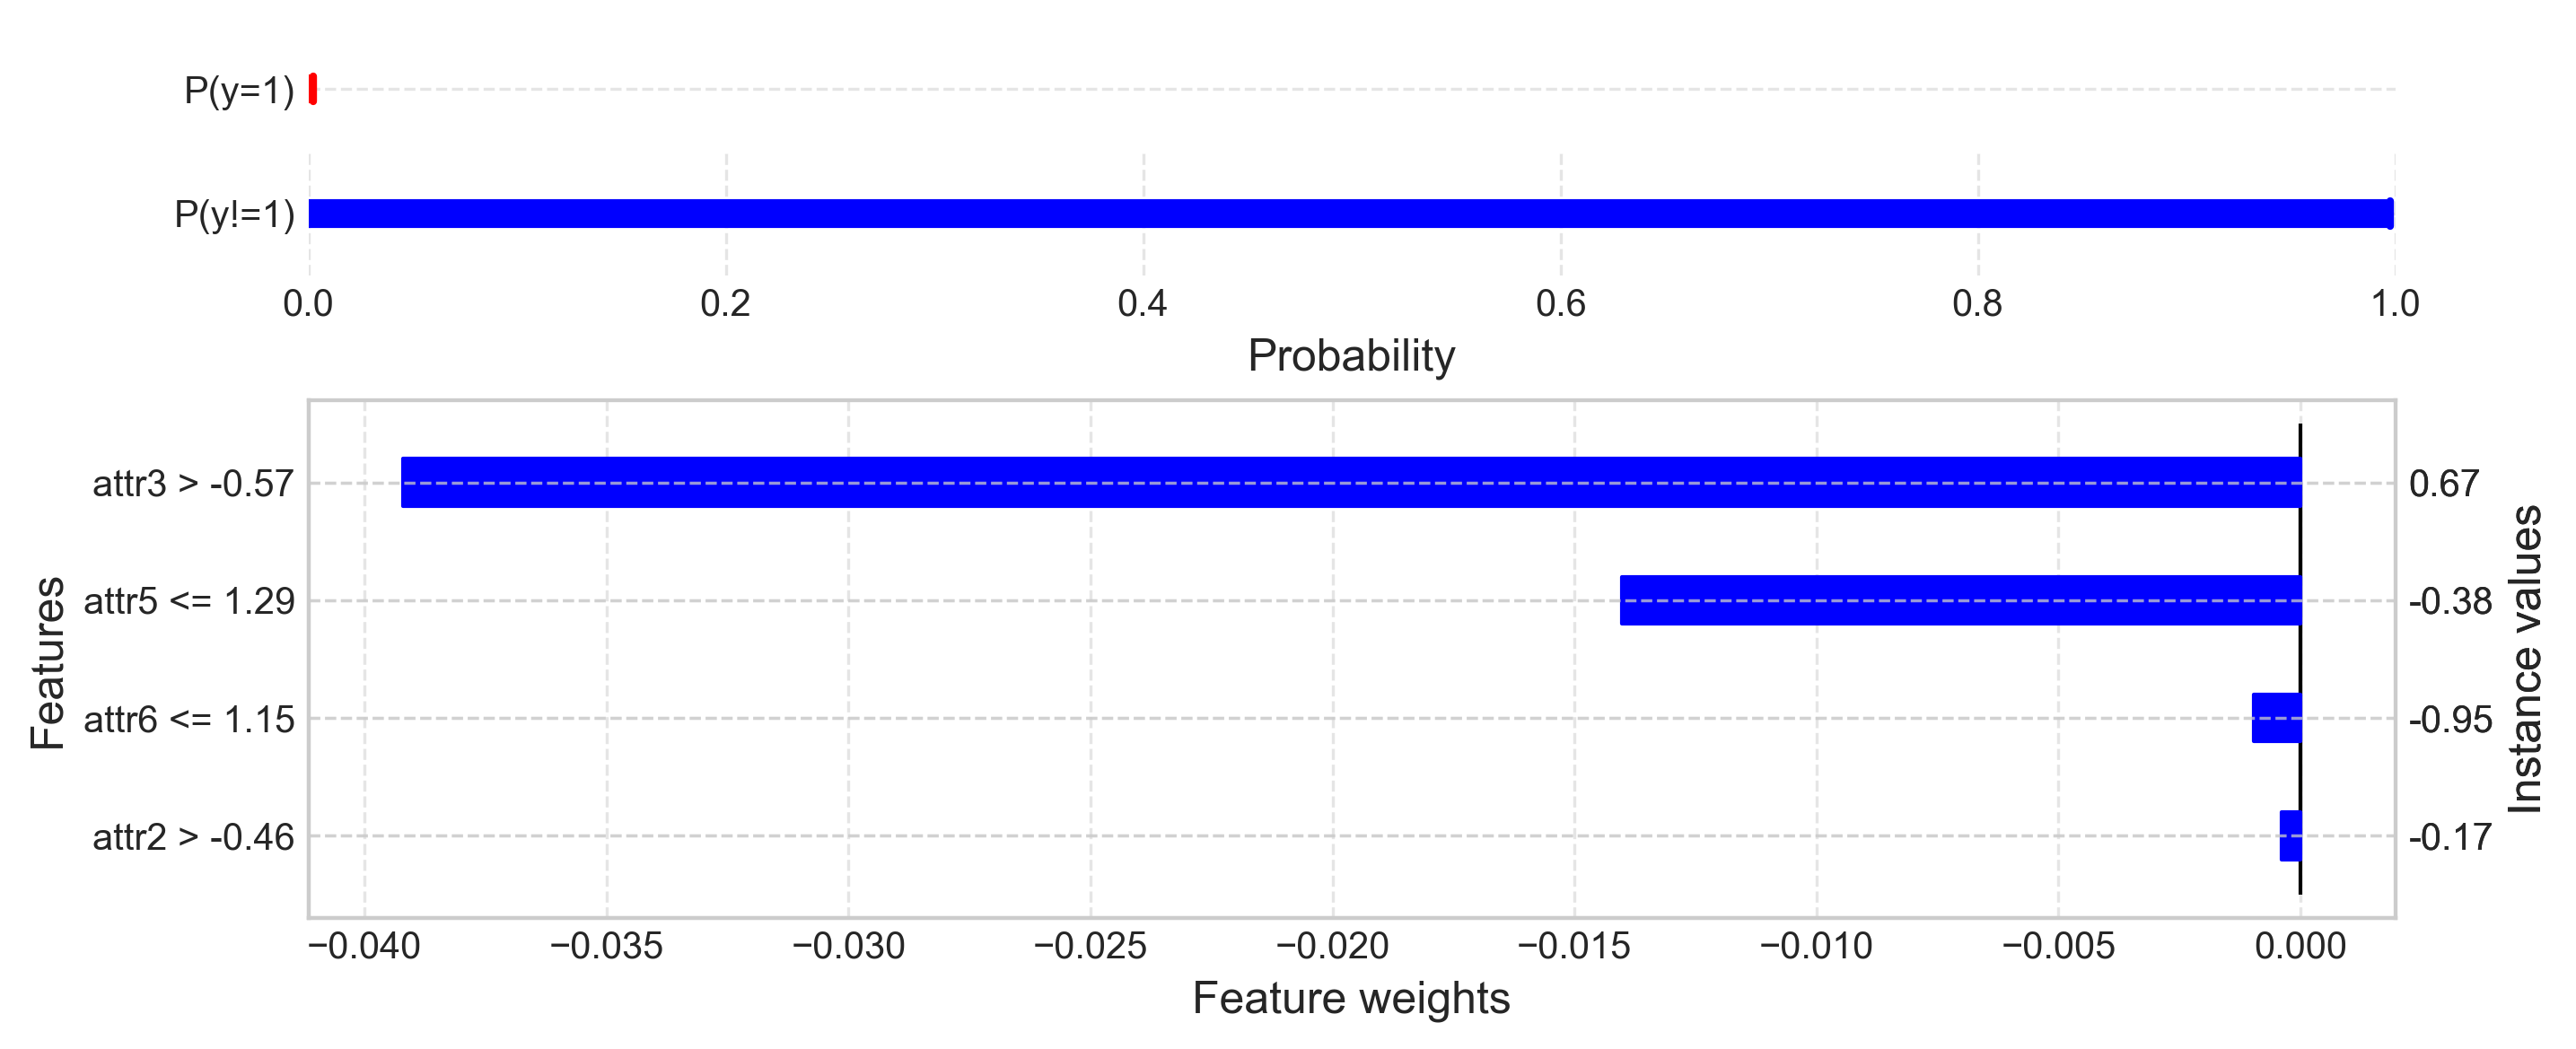

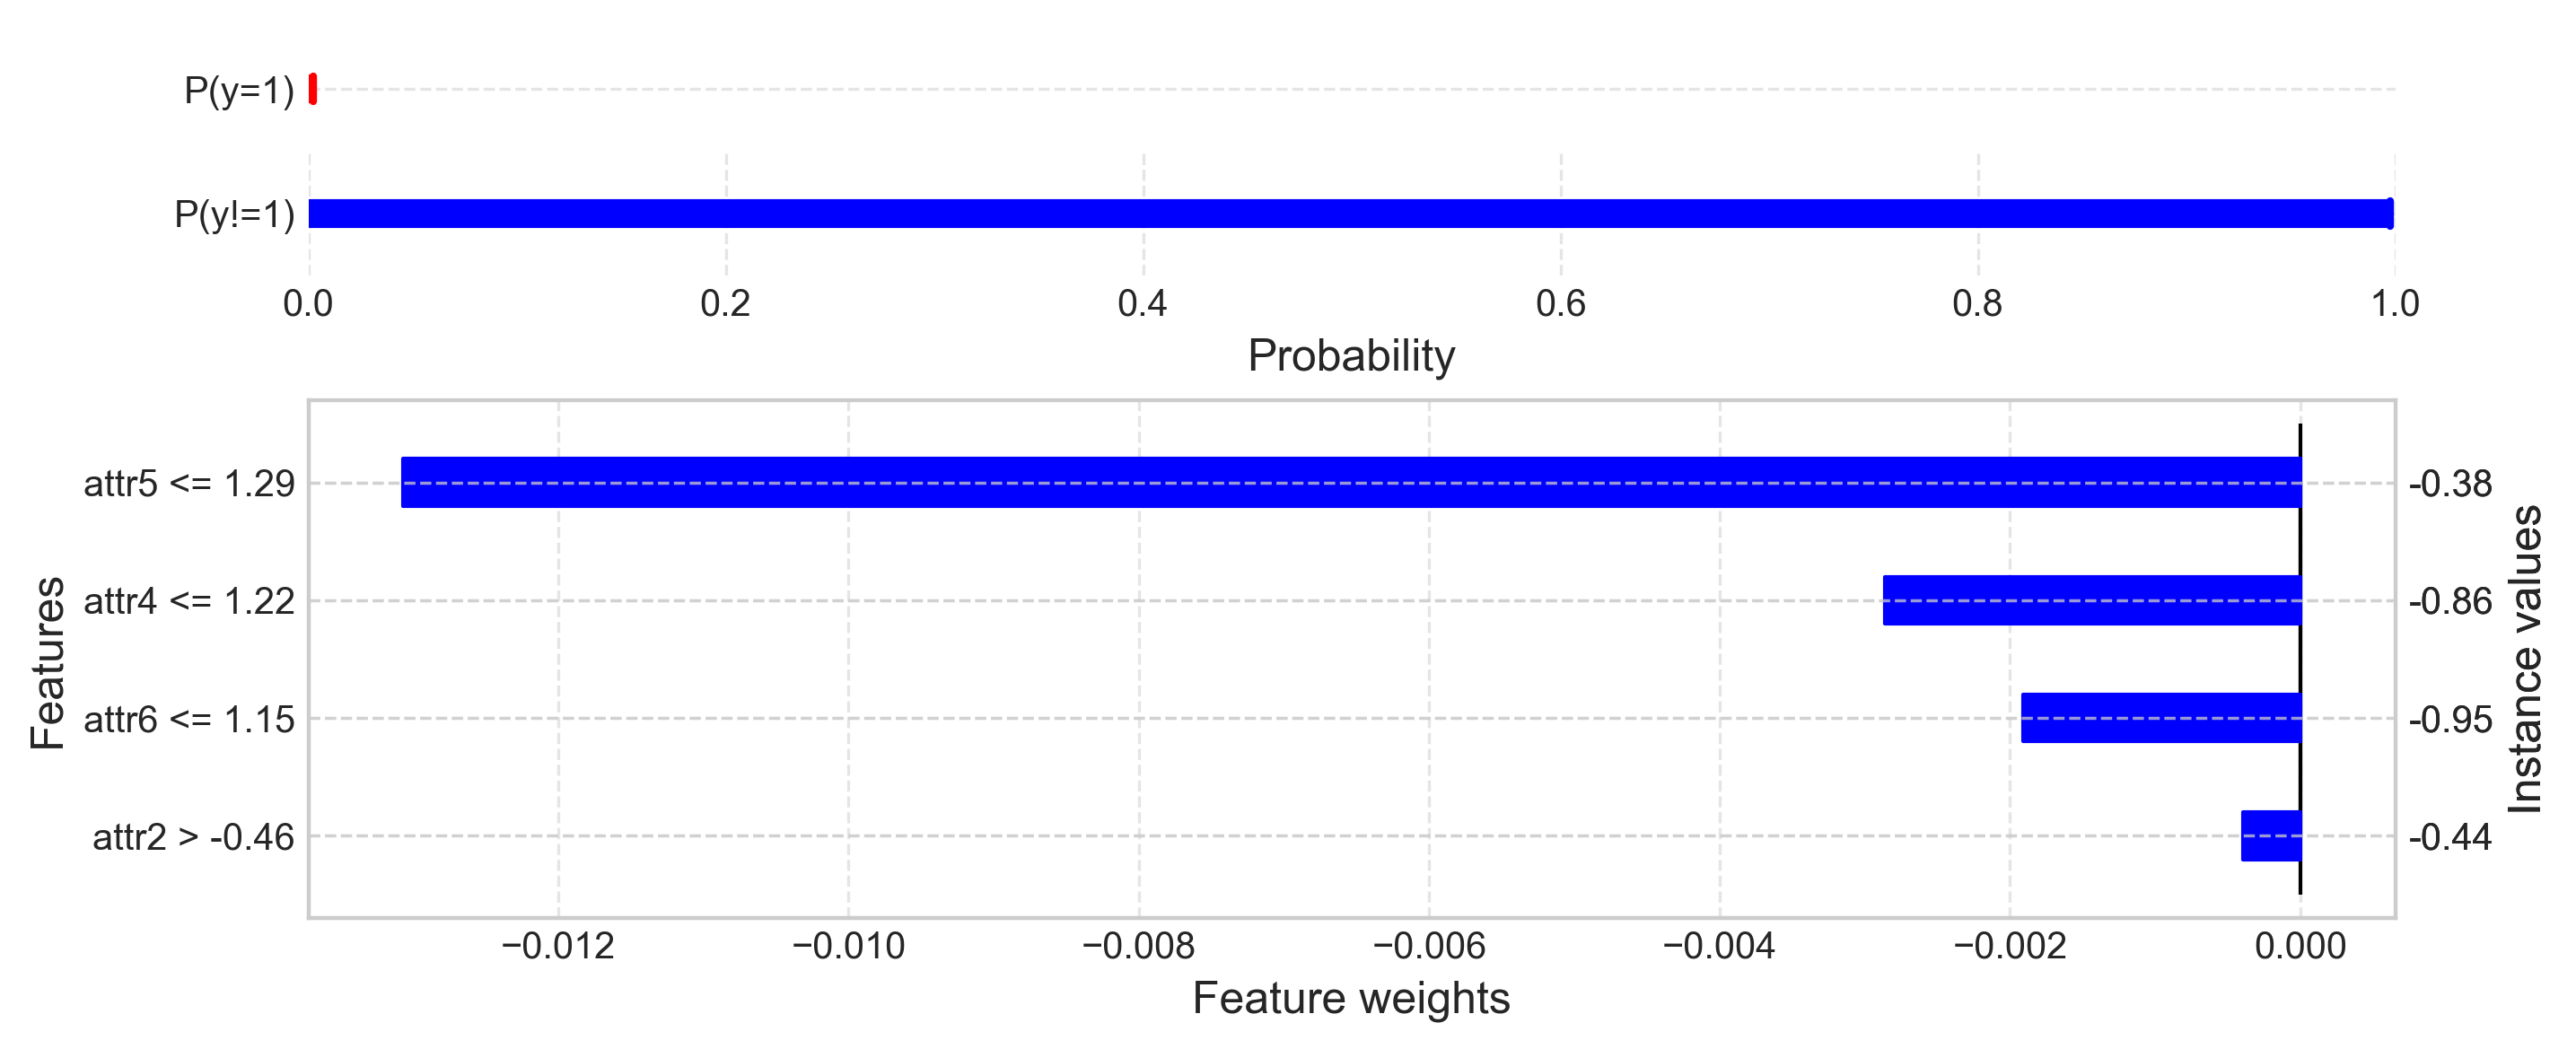

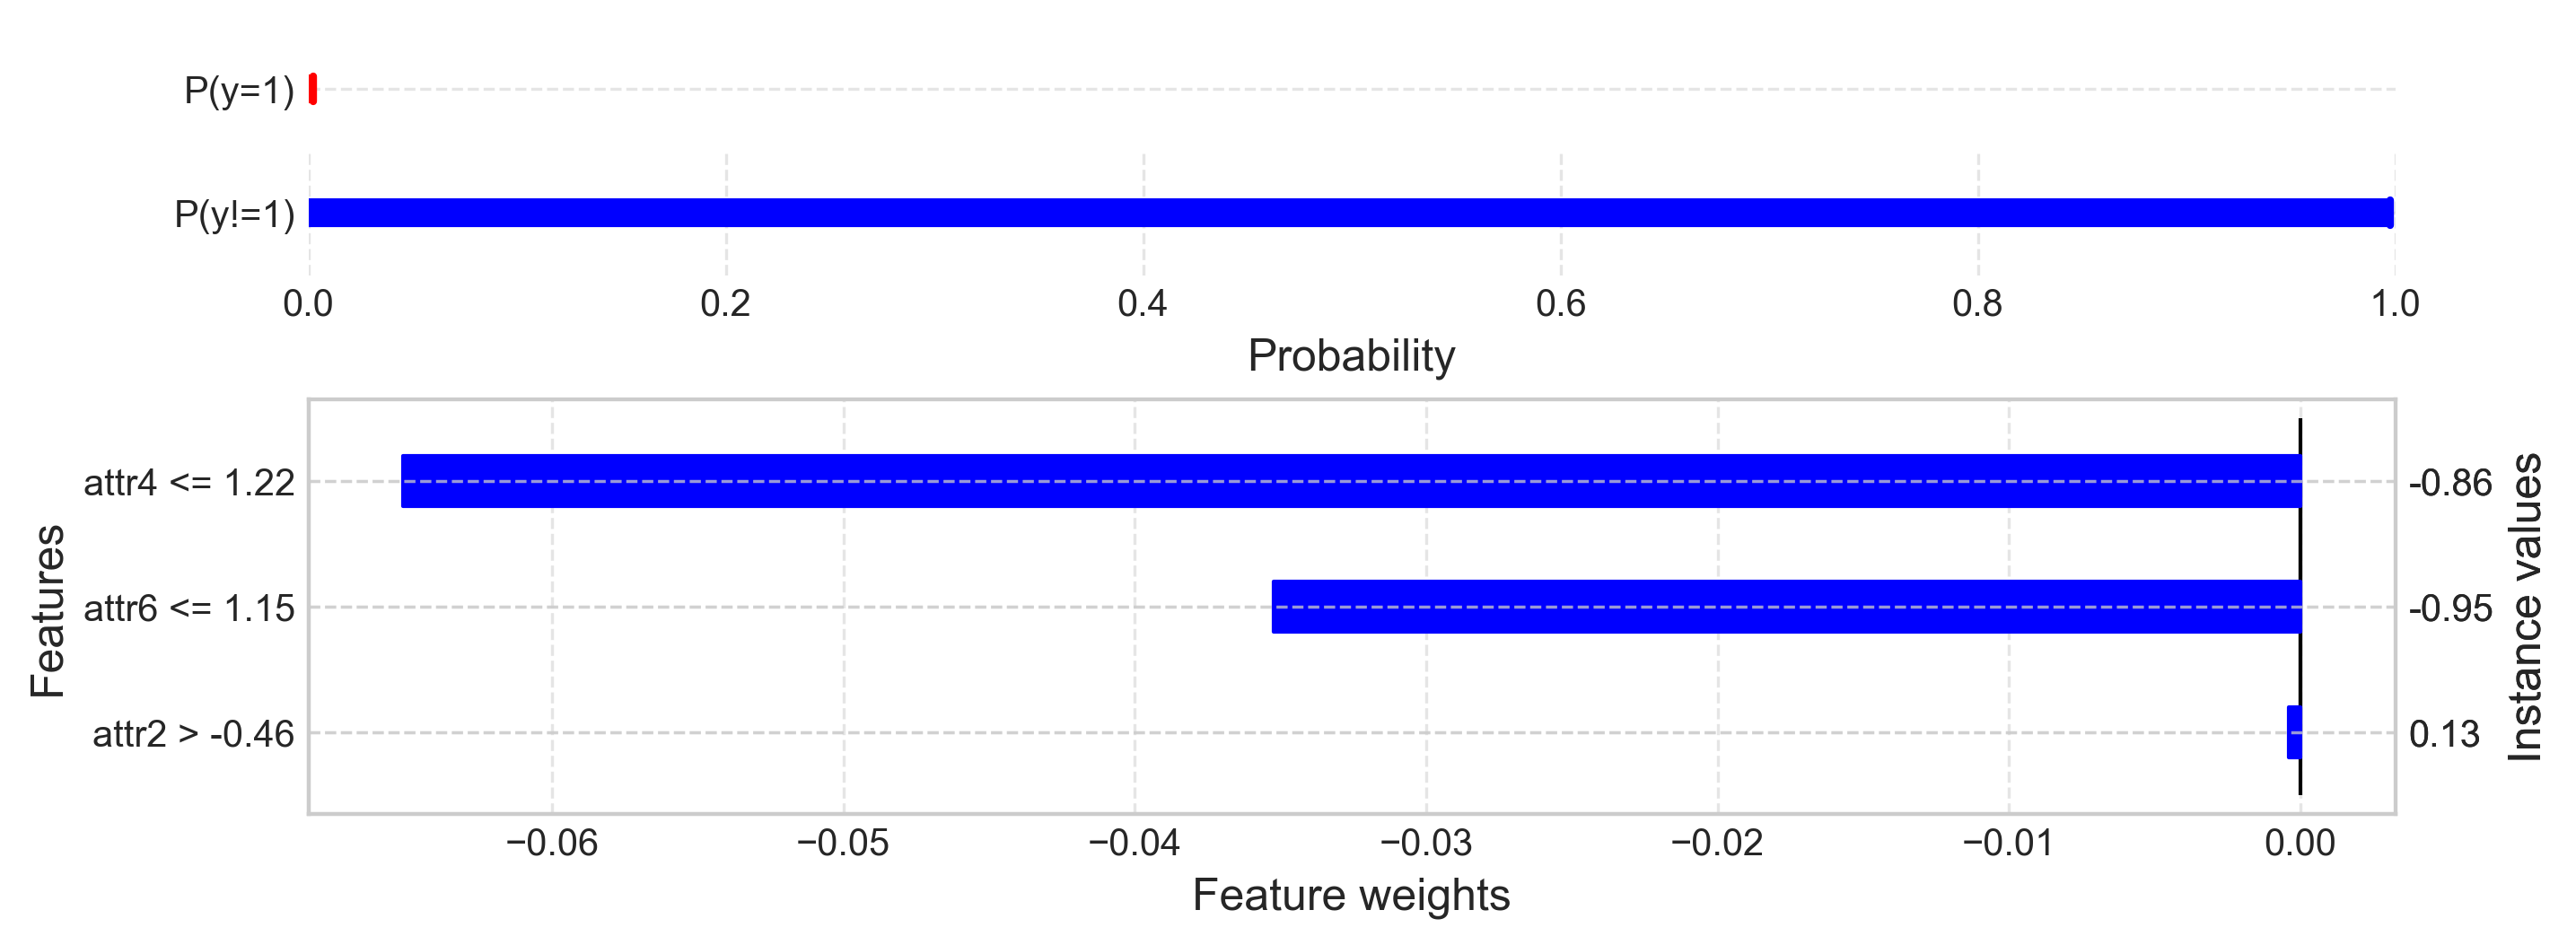

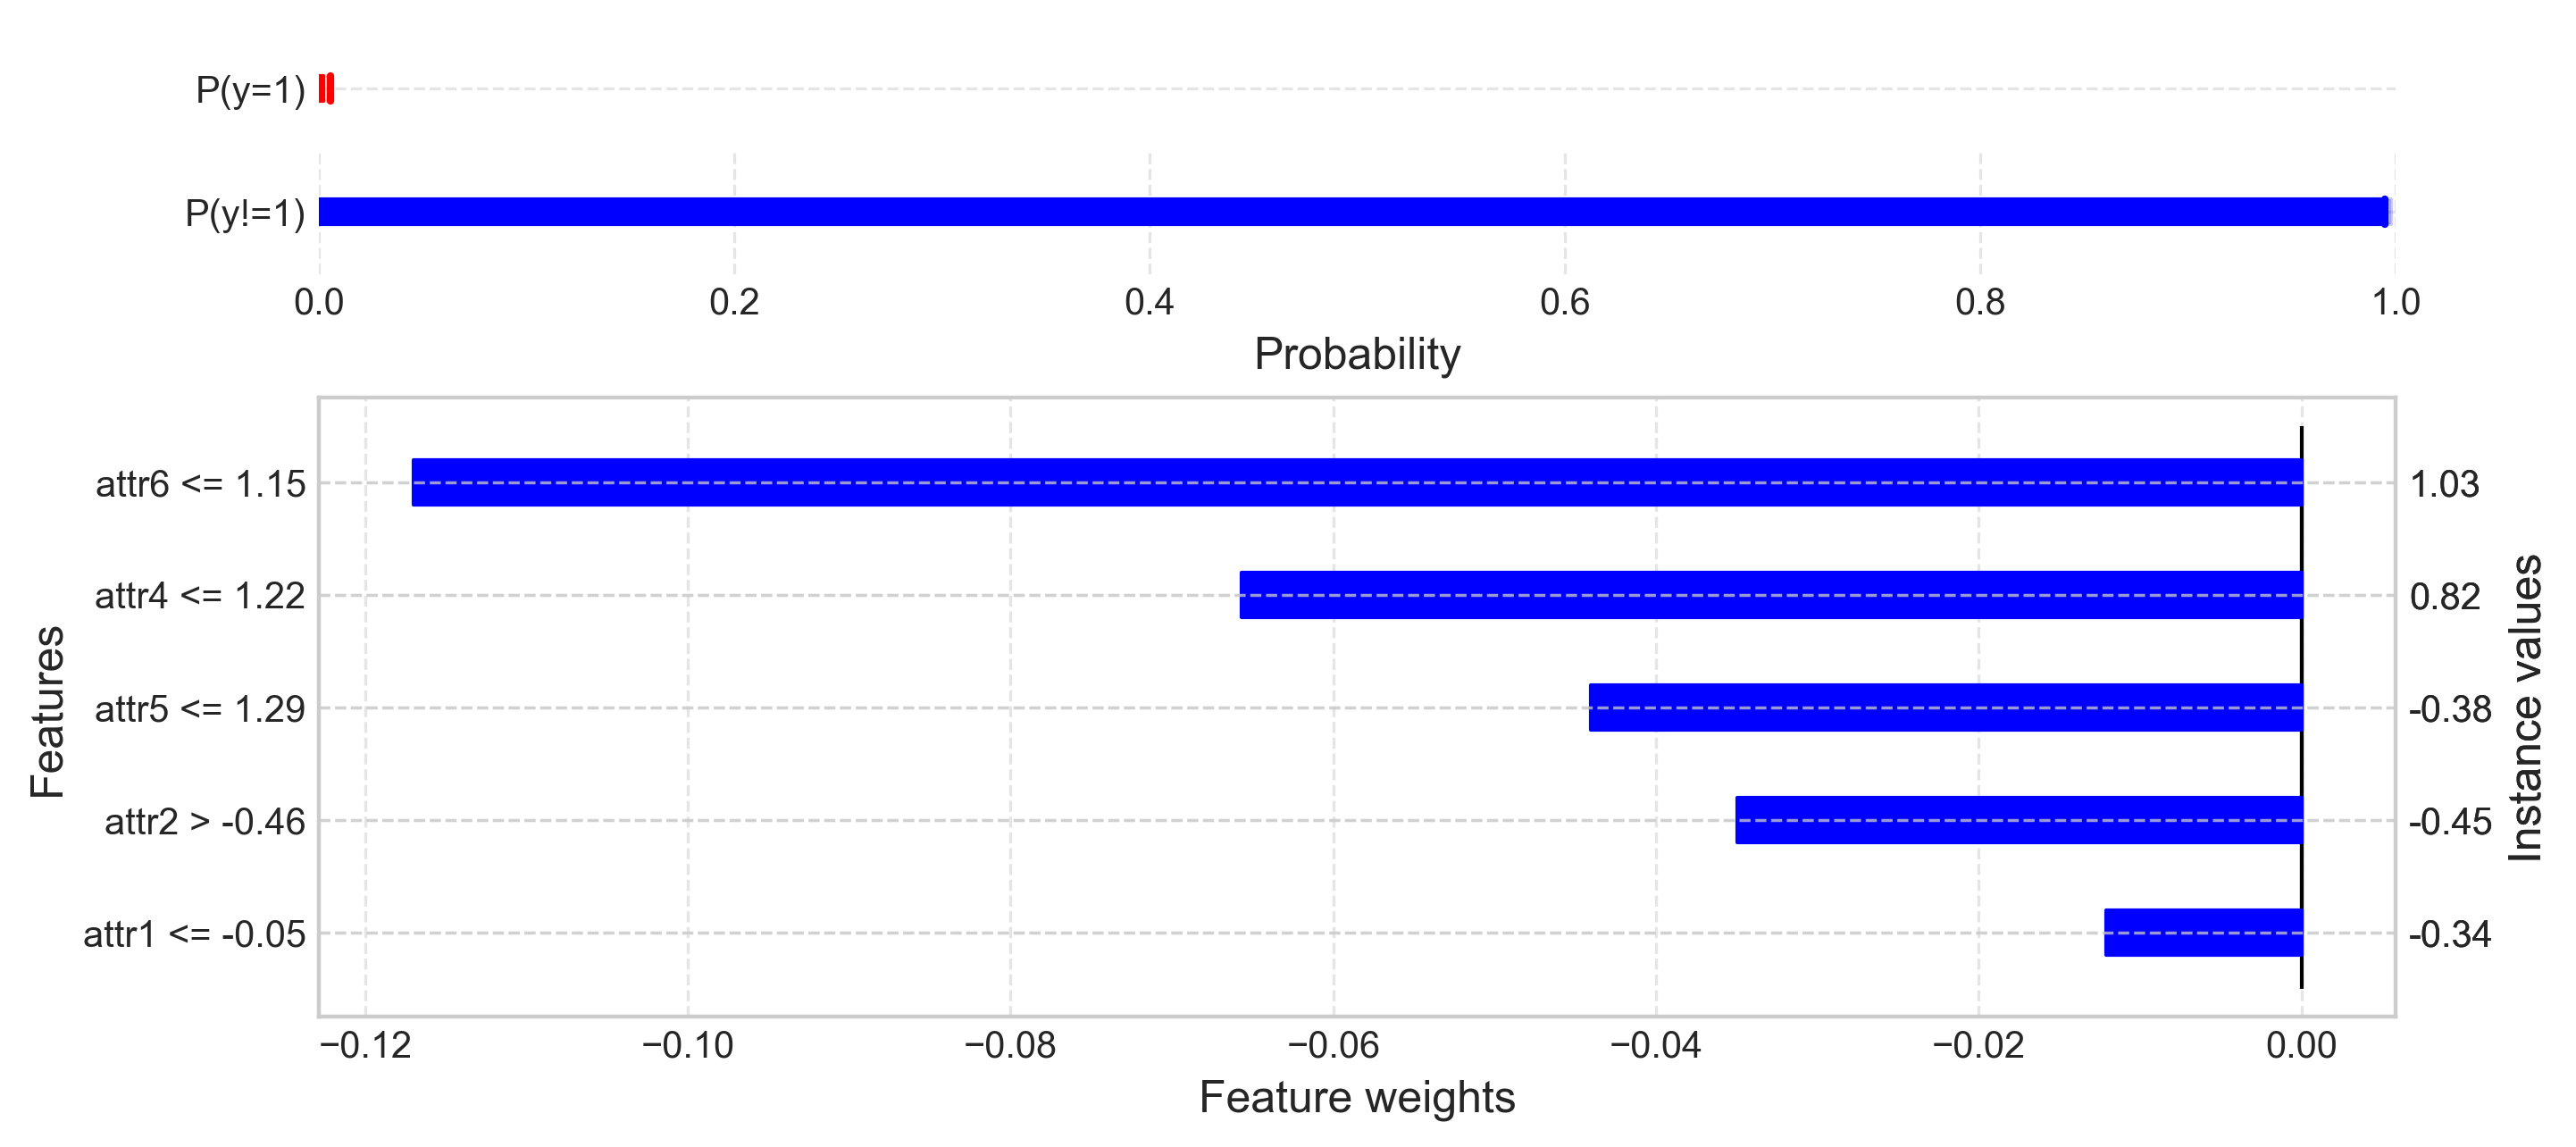

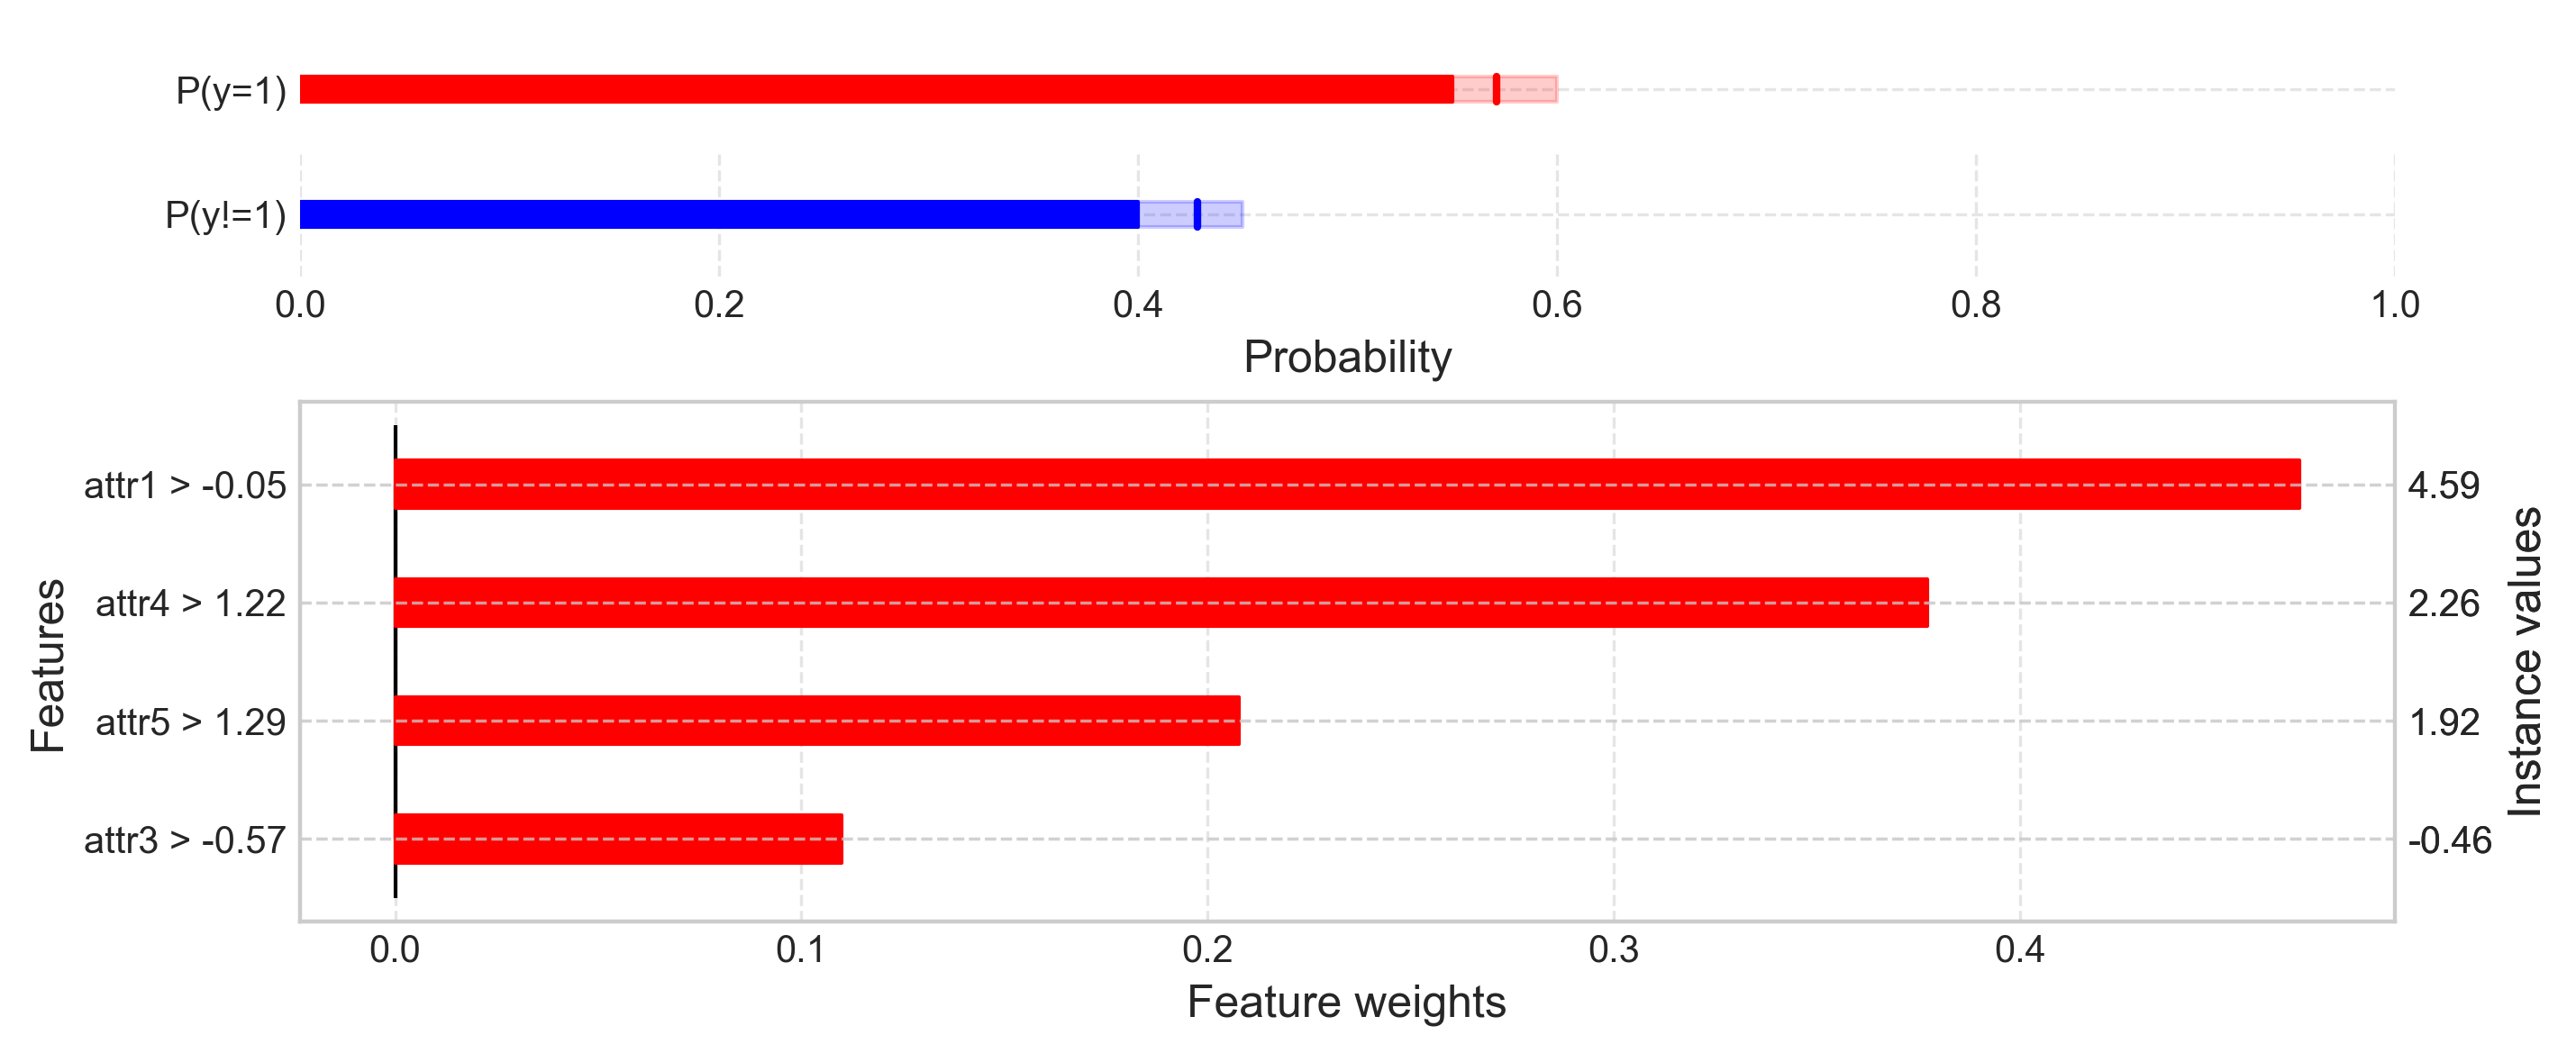

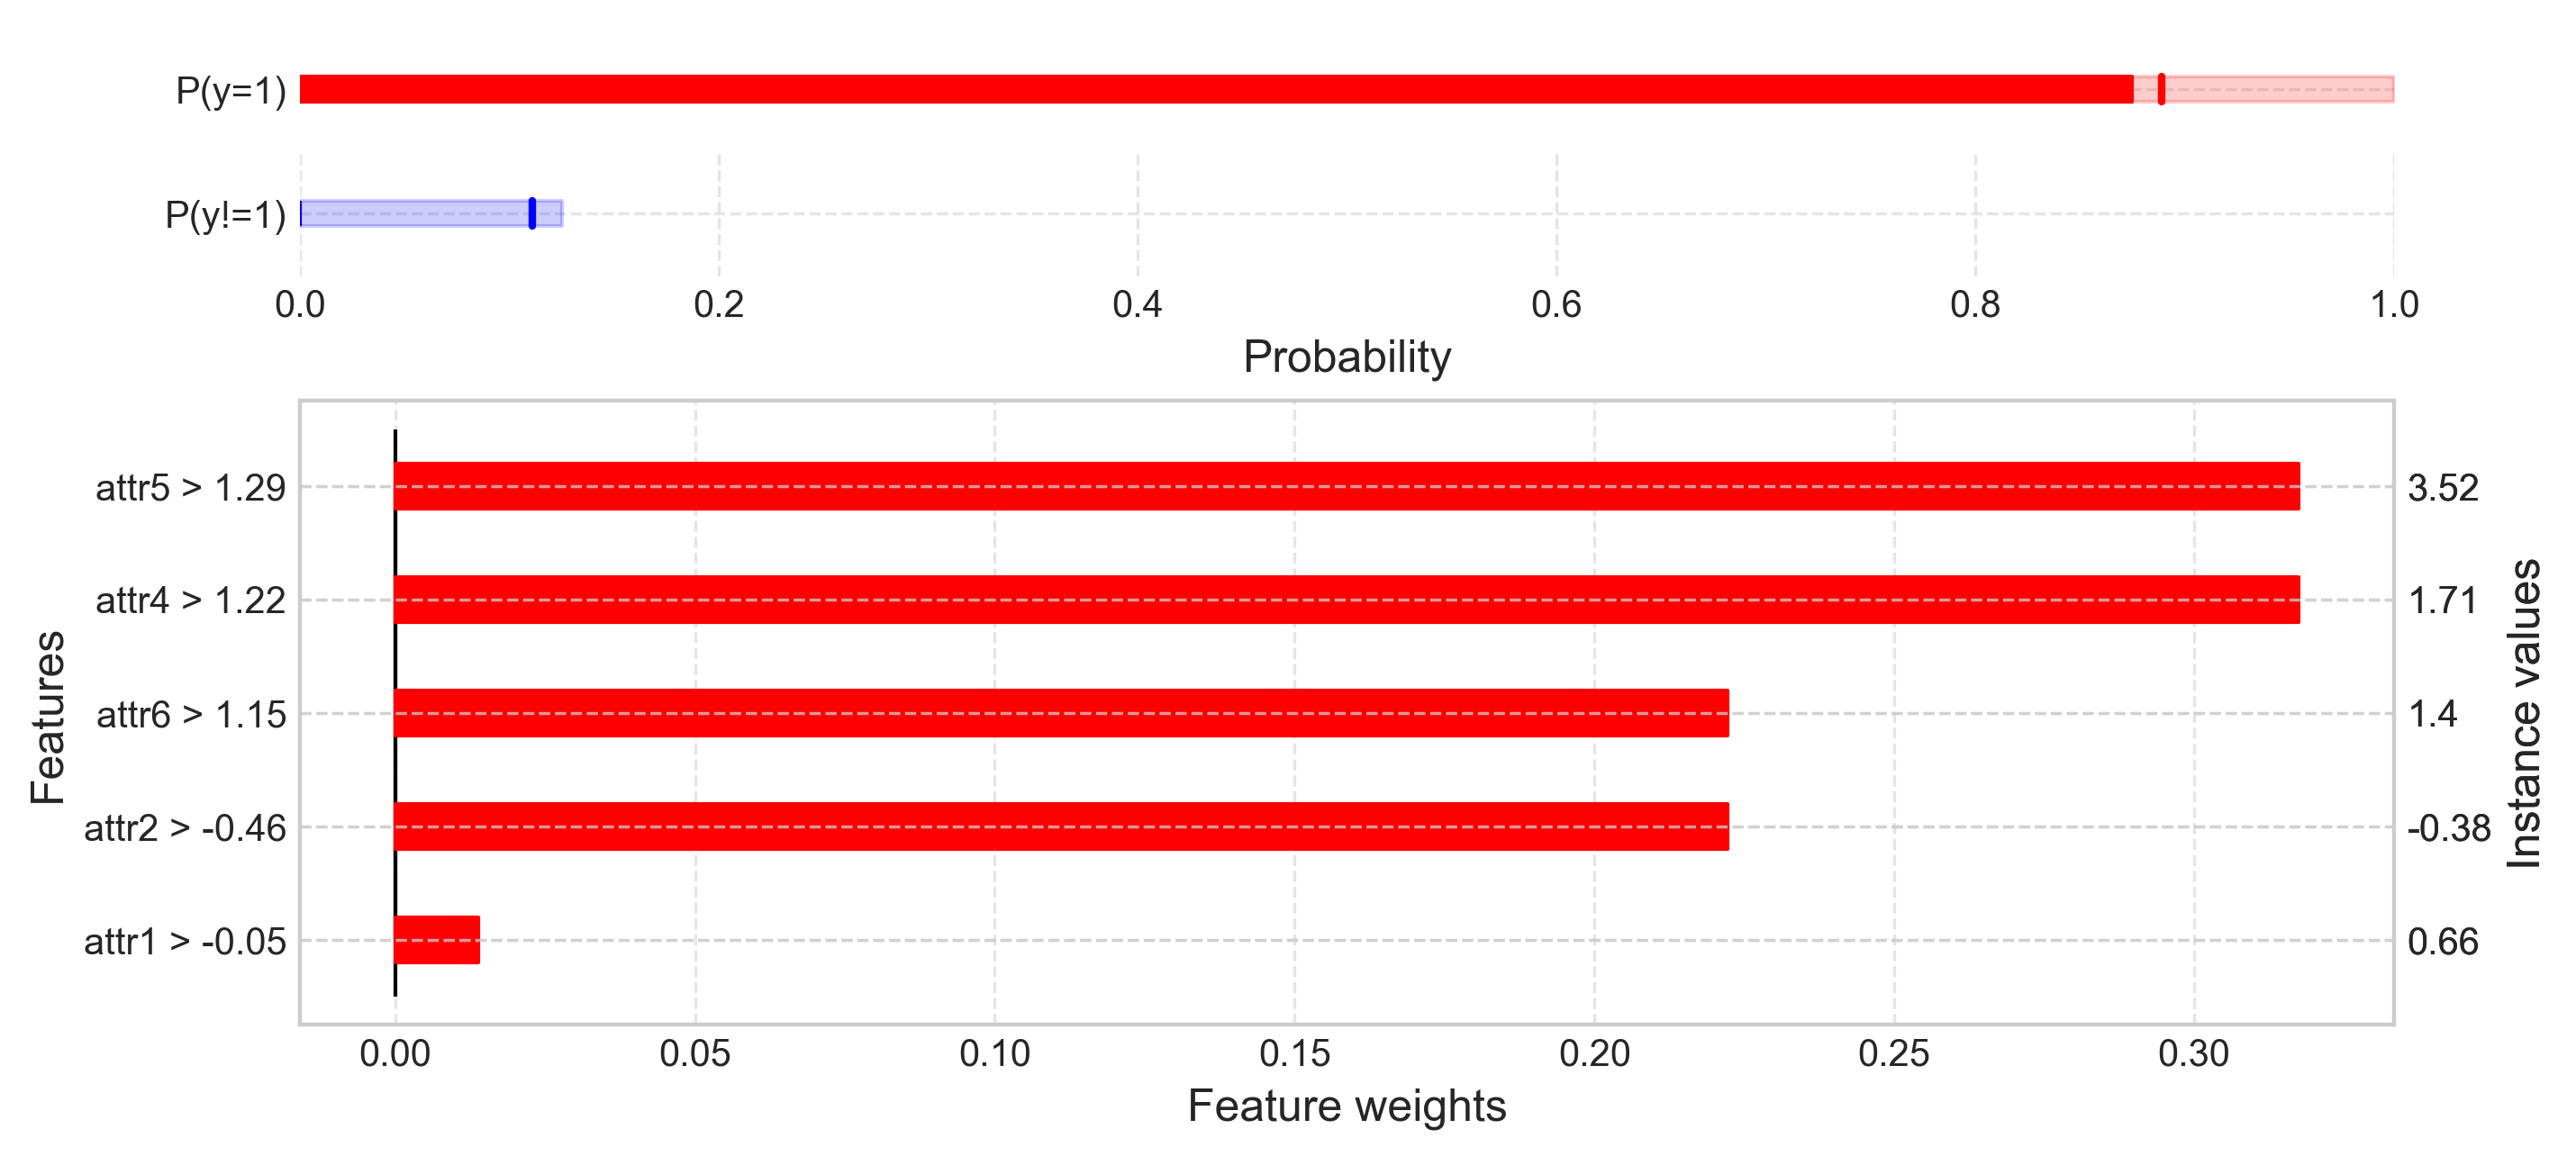

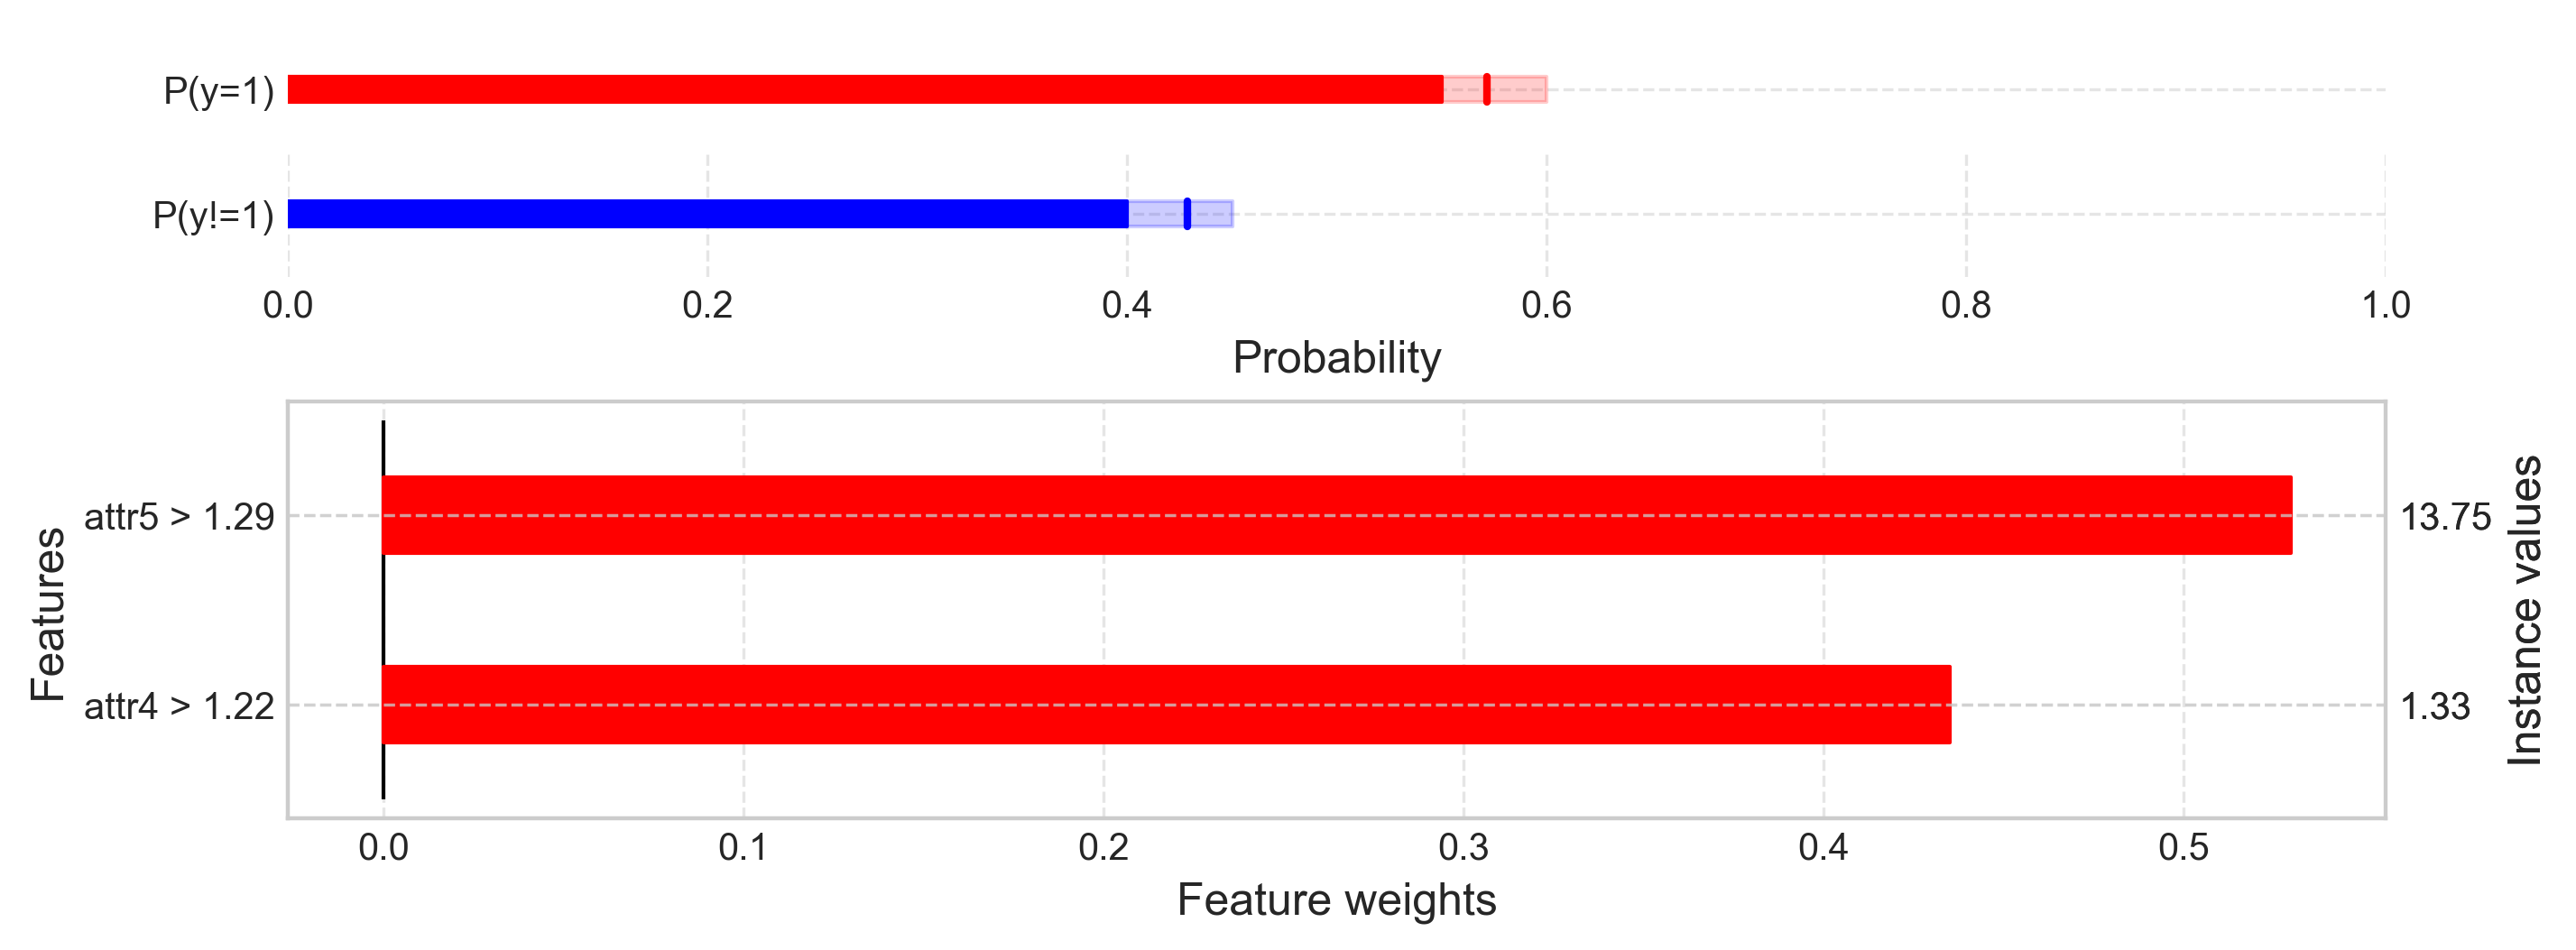

In [10]:
factual_explanations.plot()

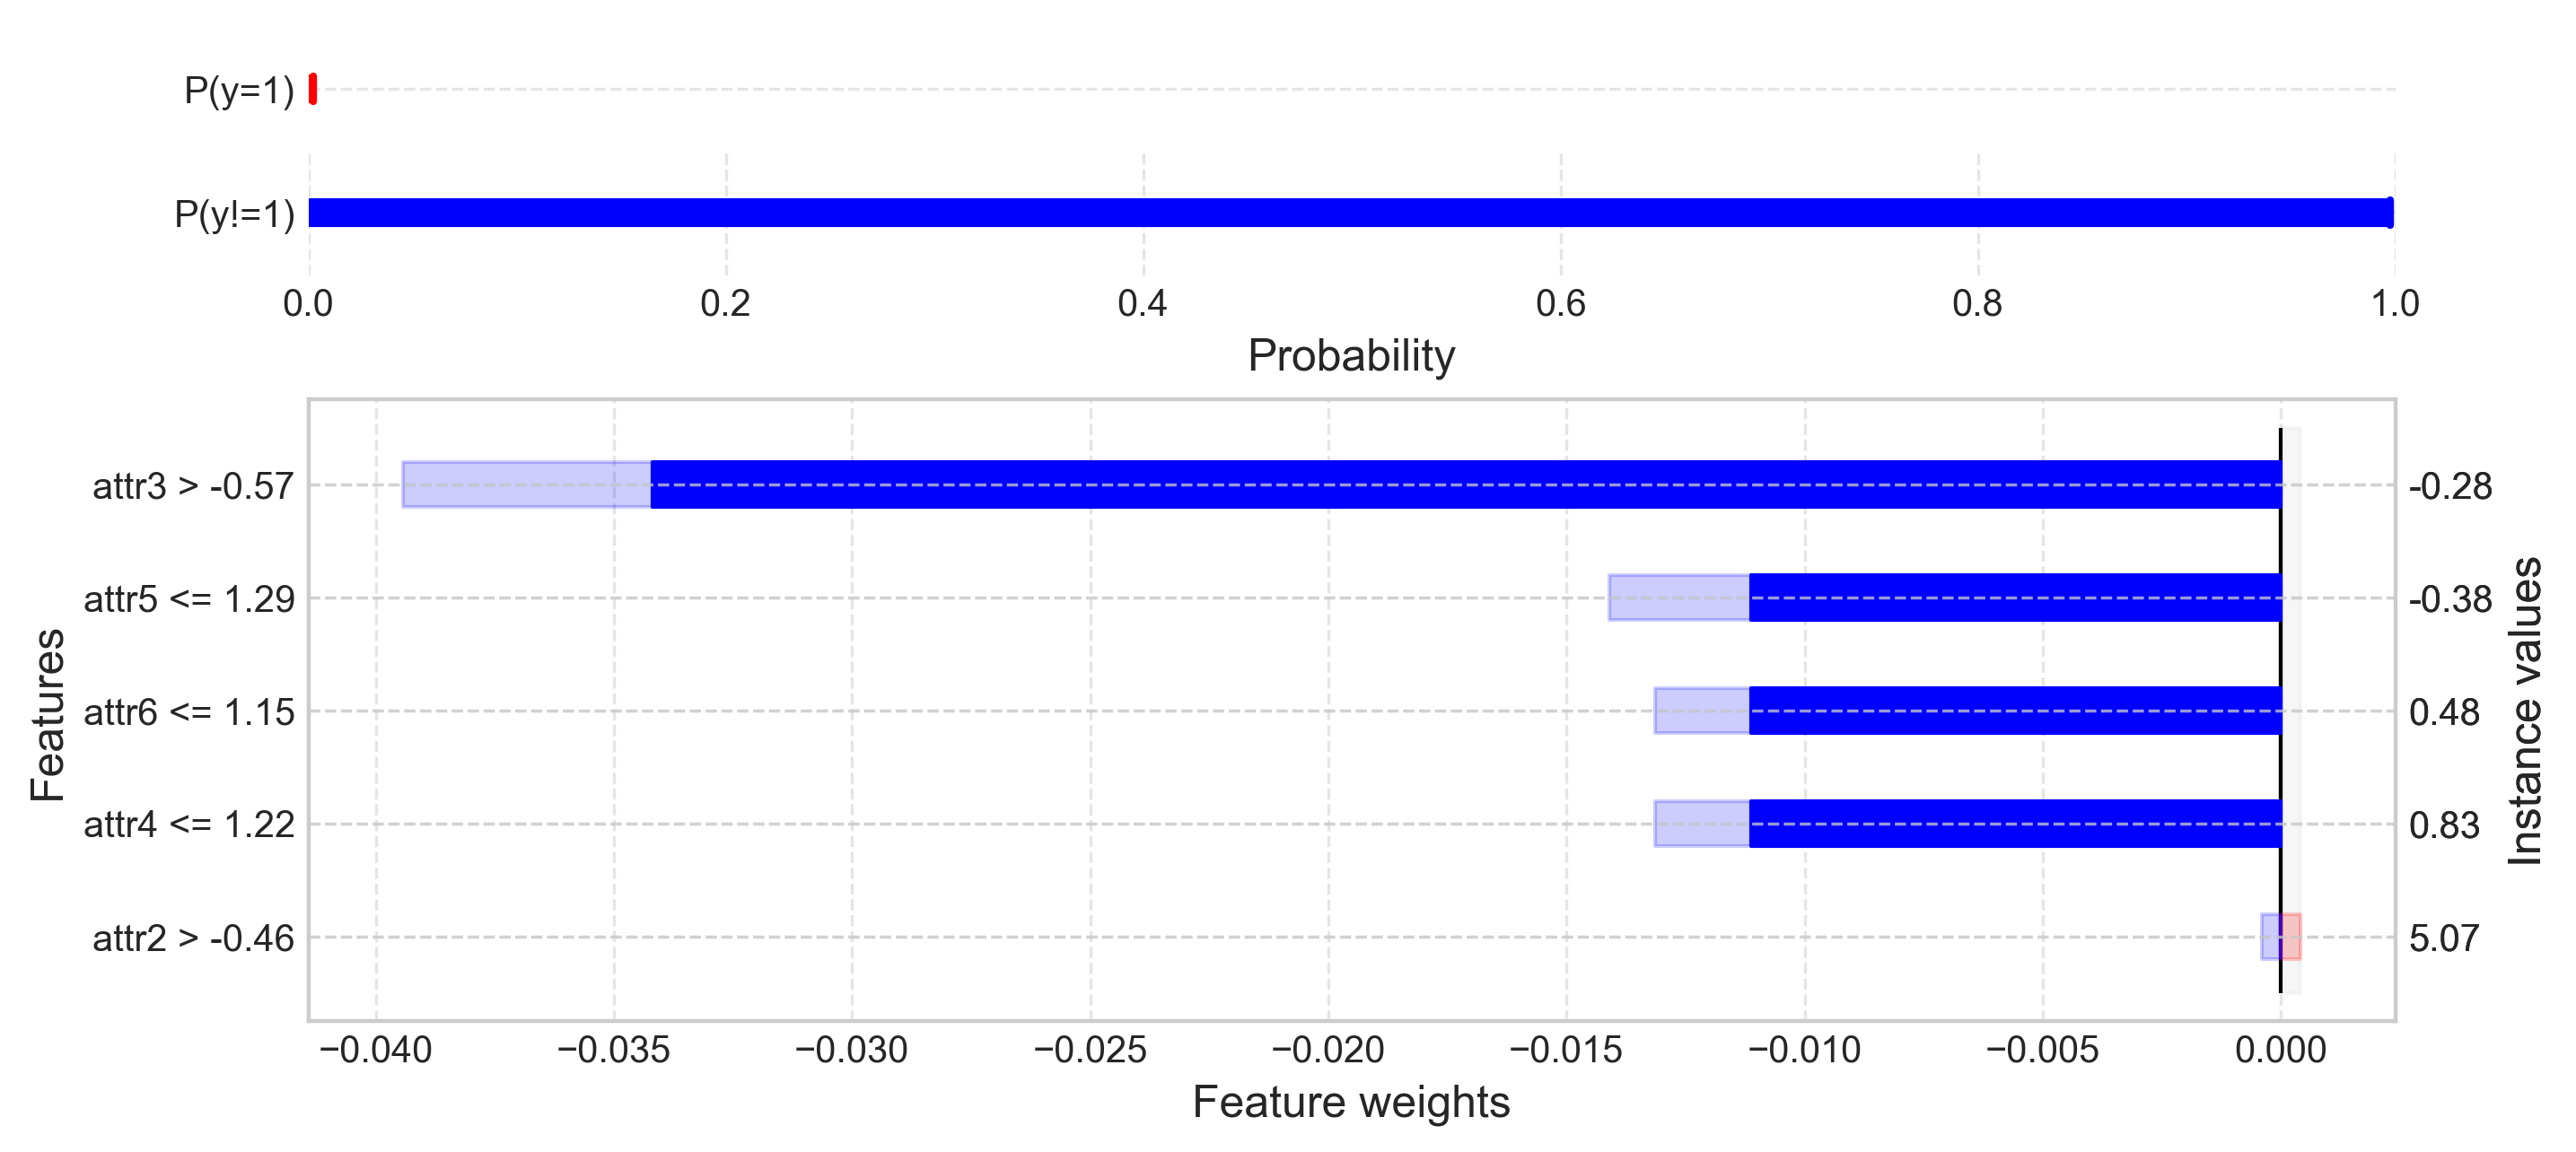

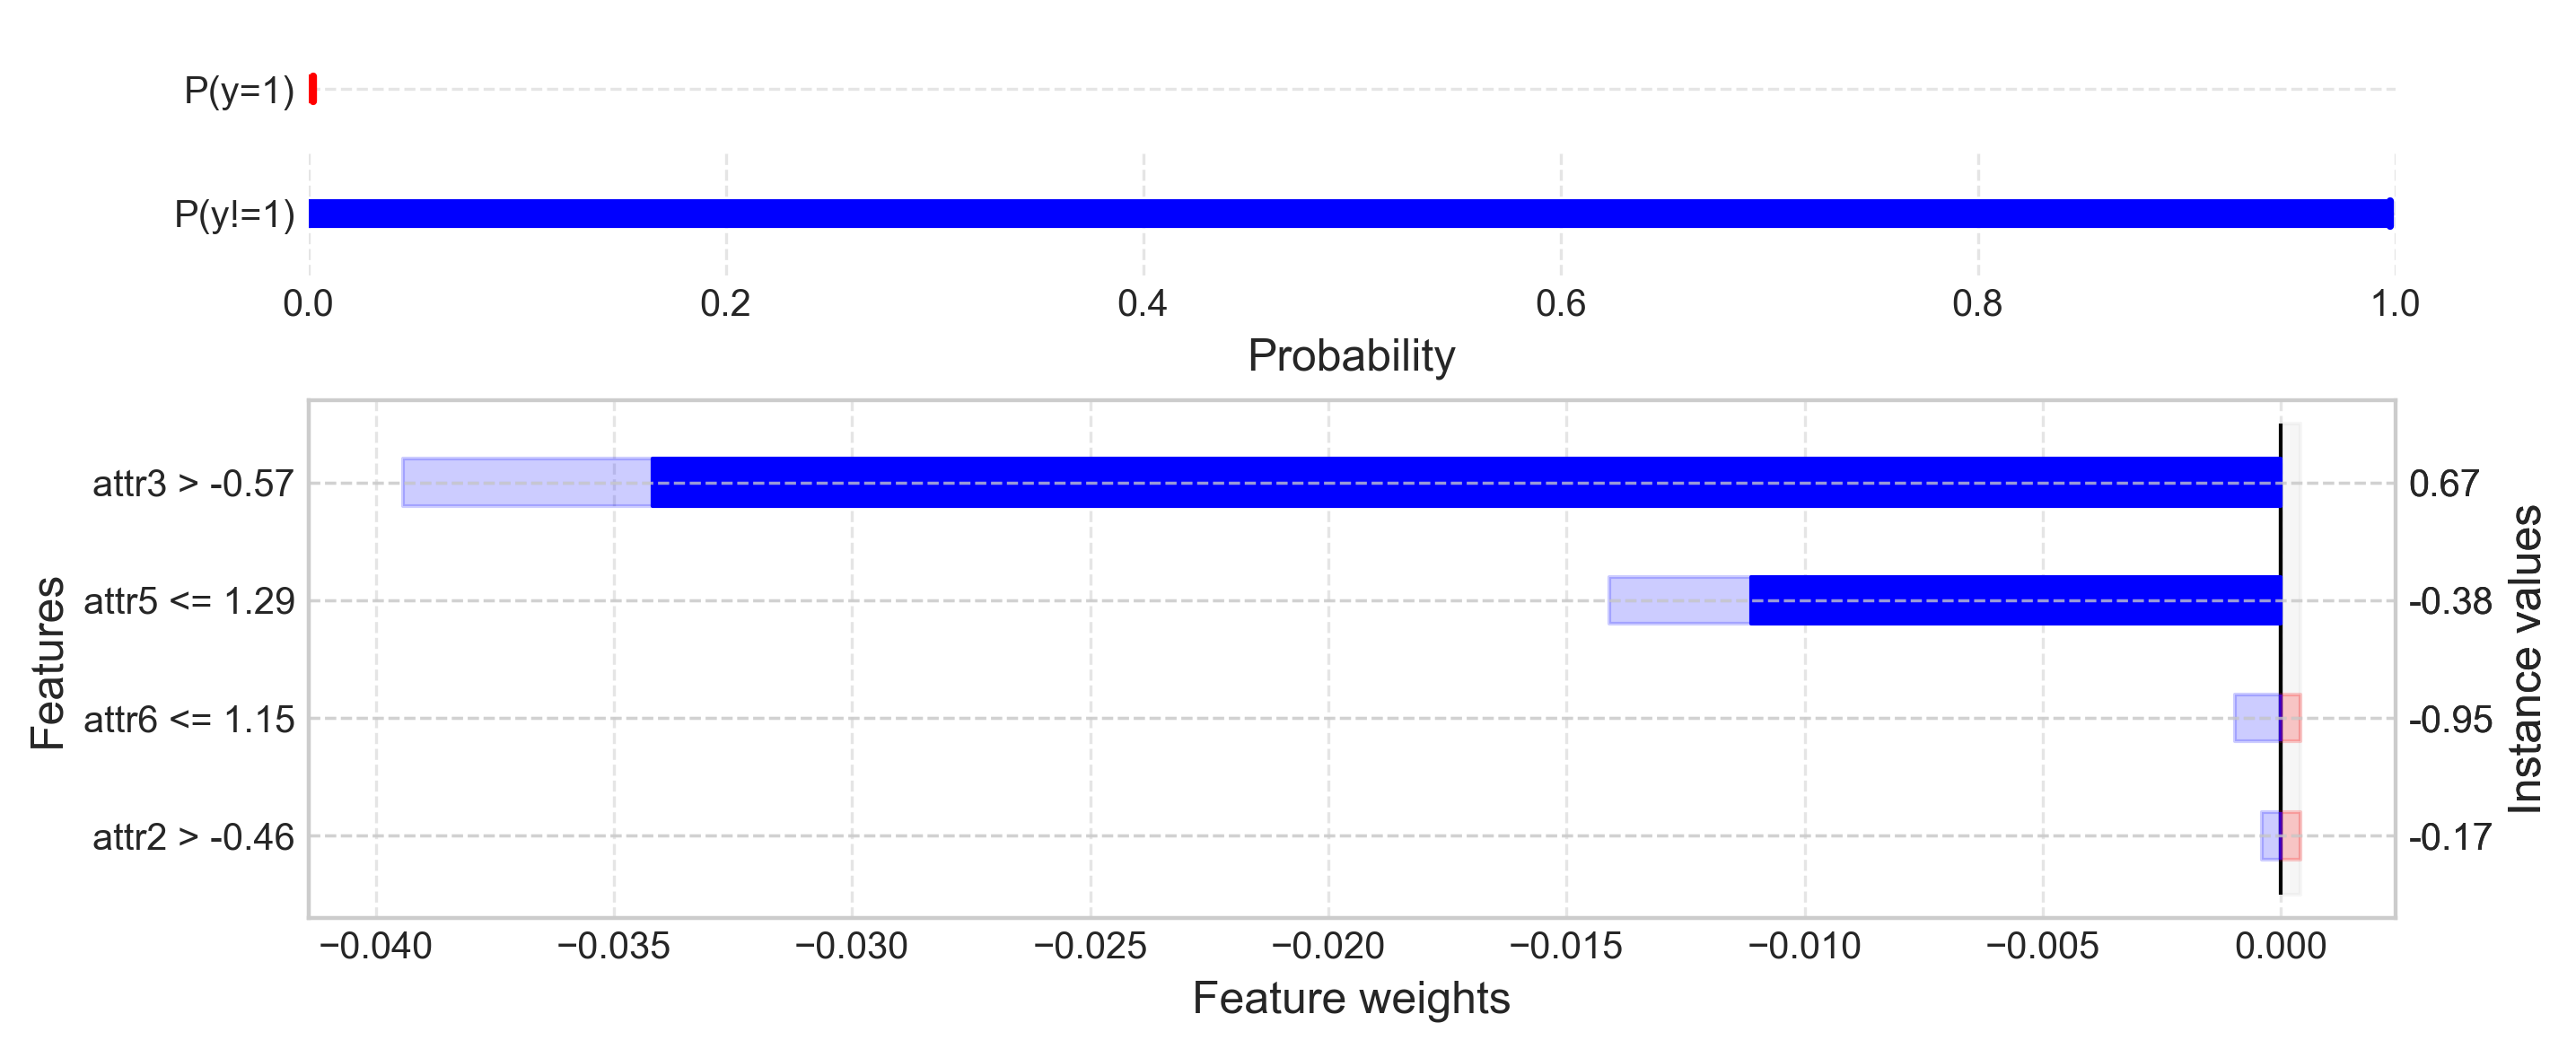

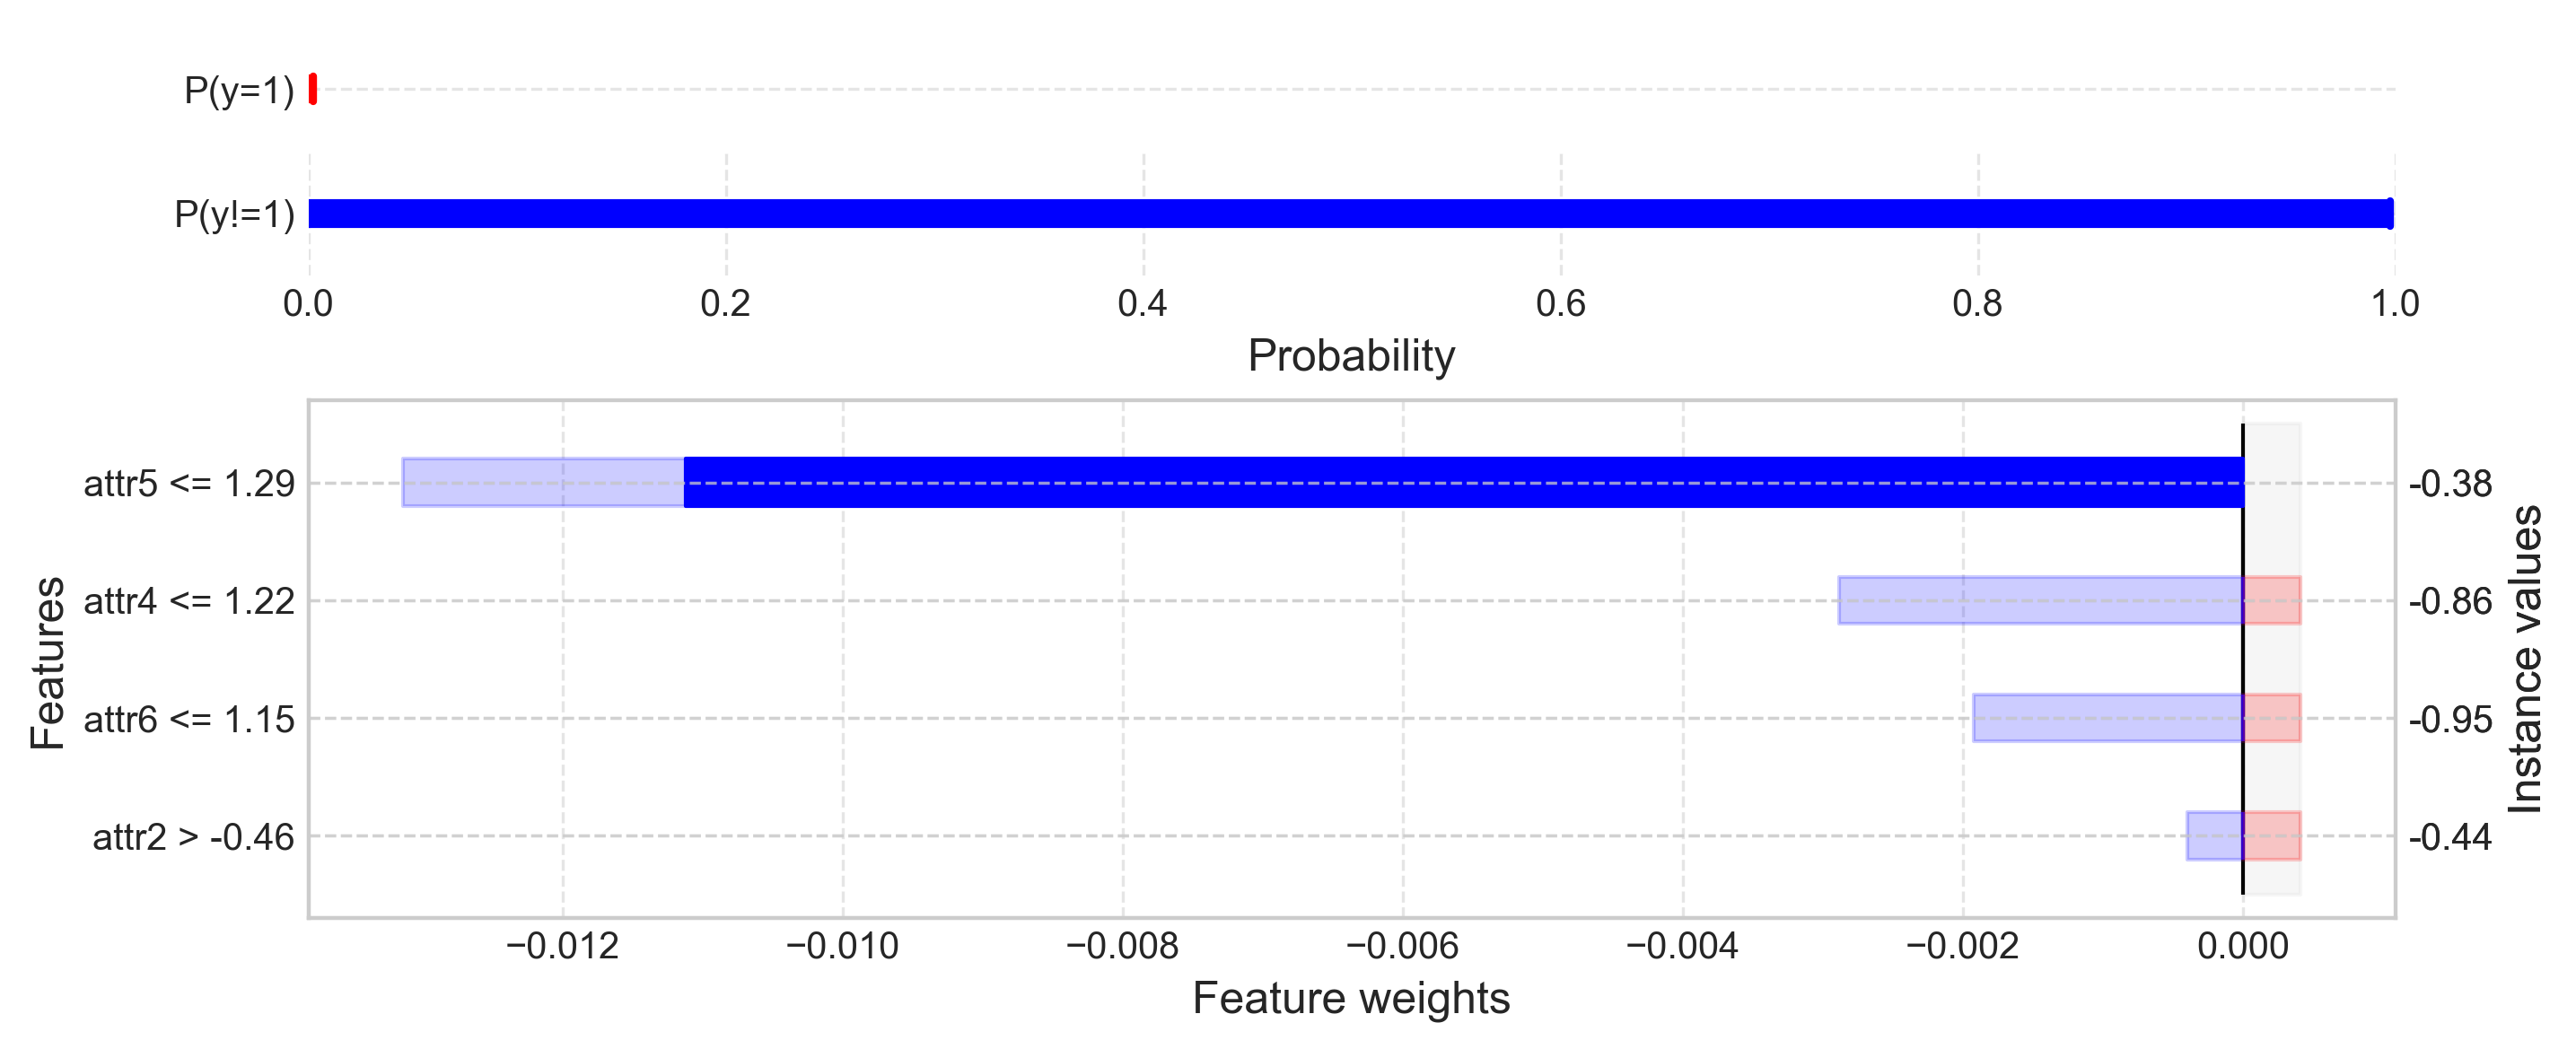

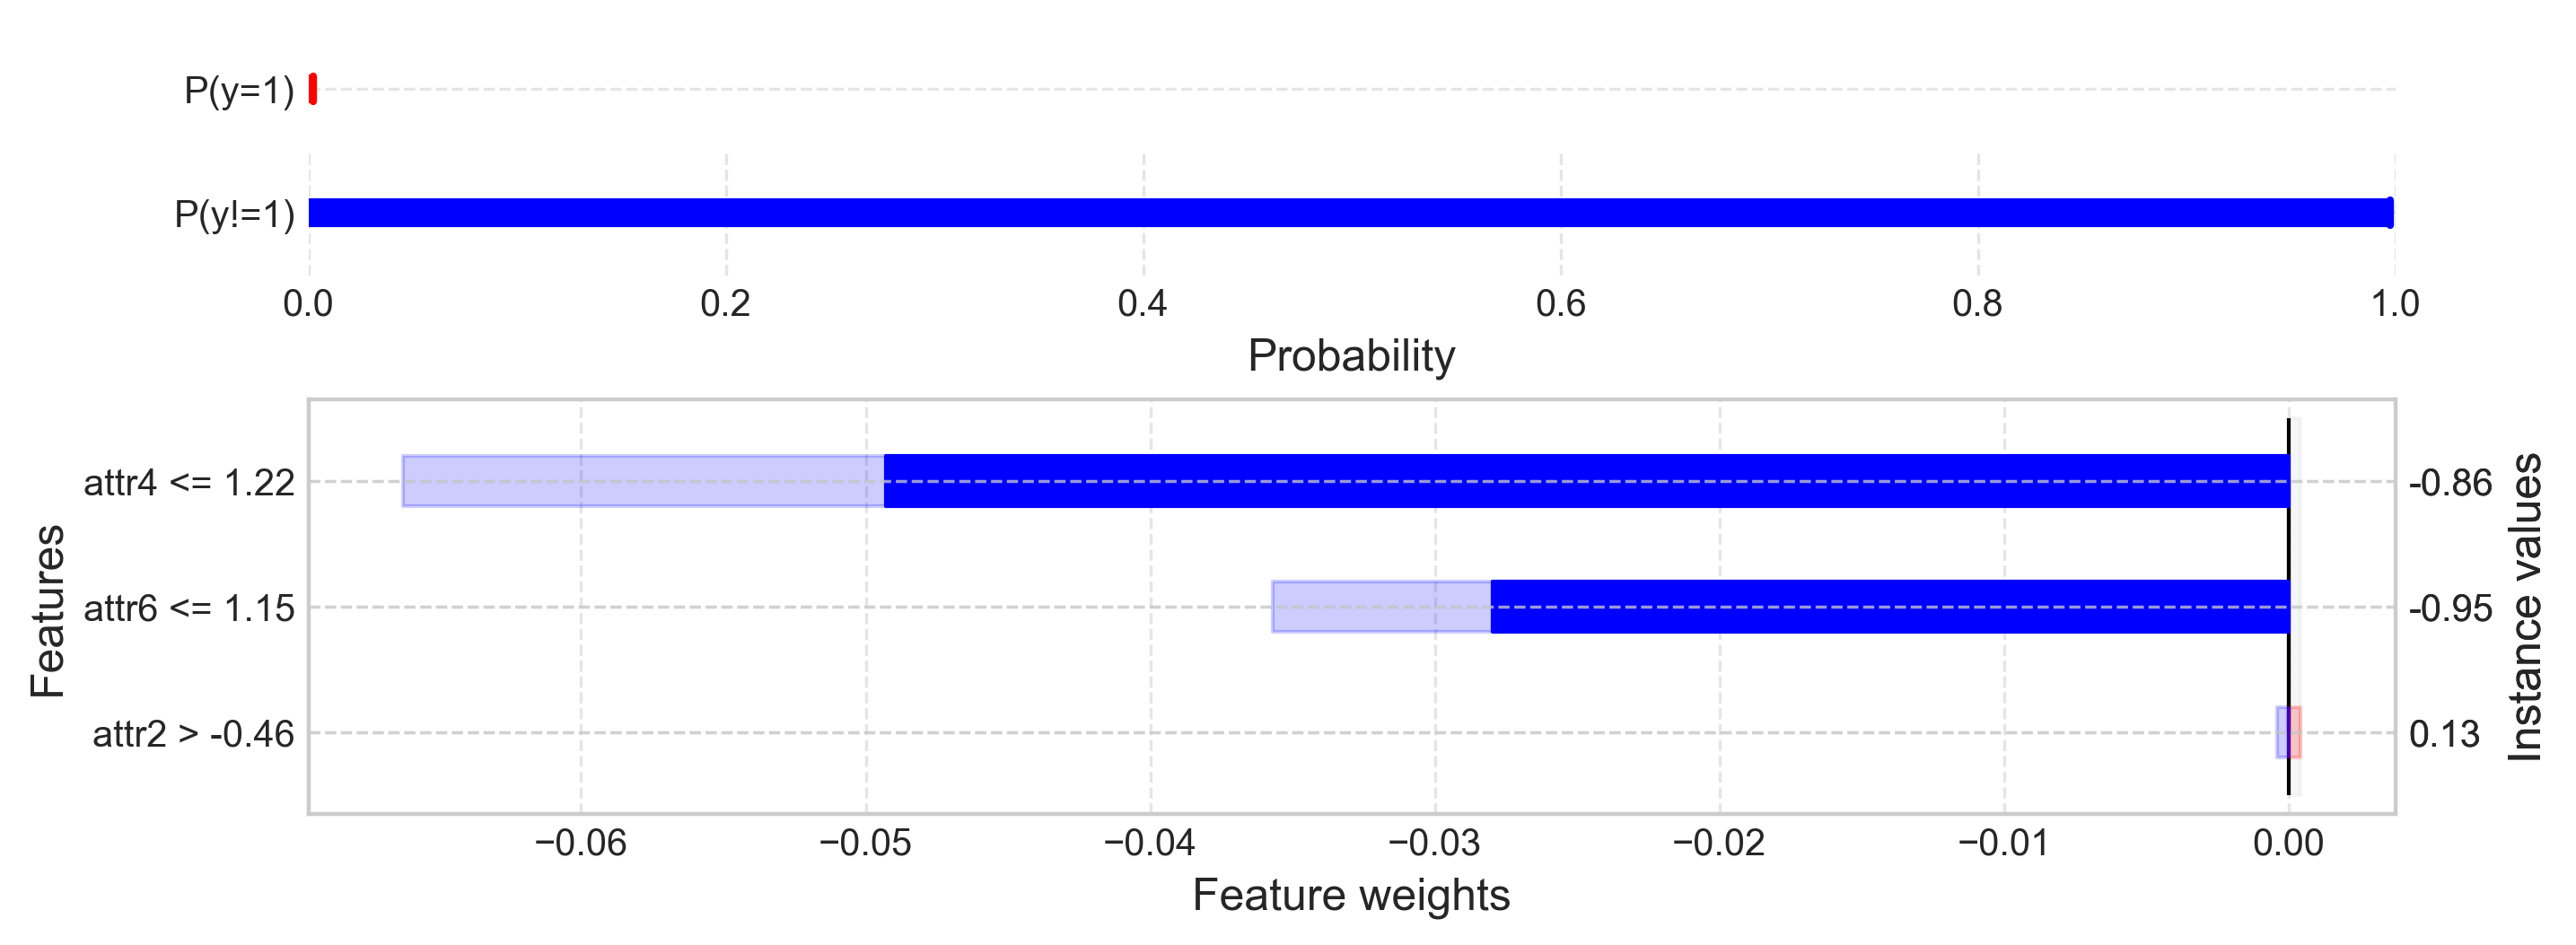

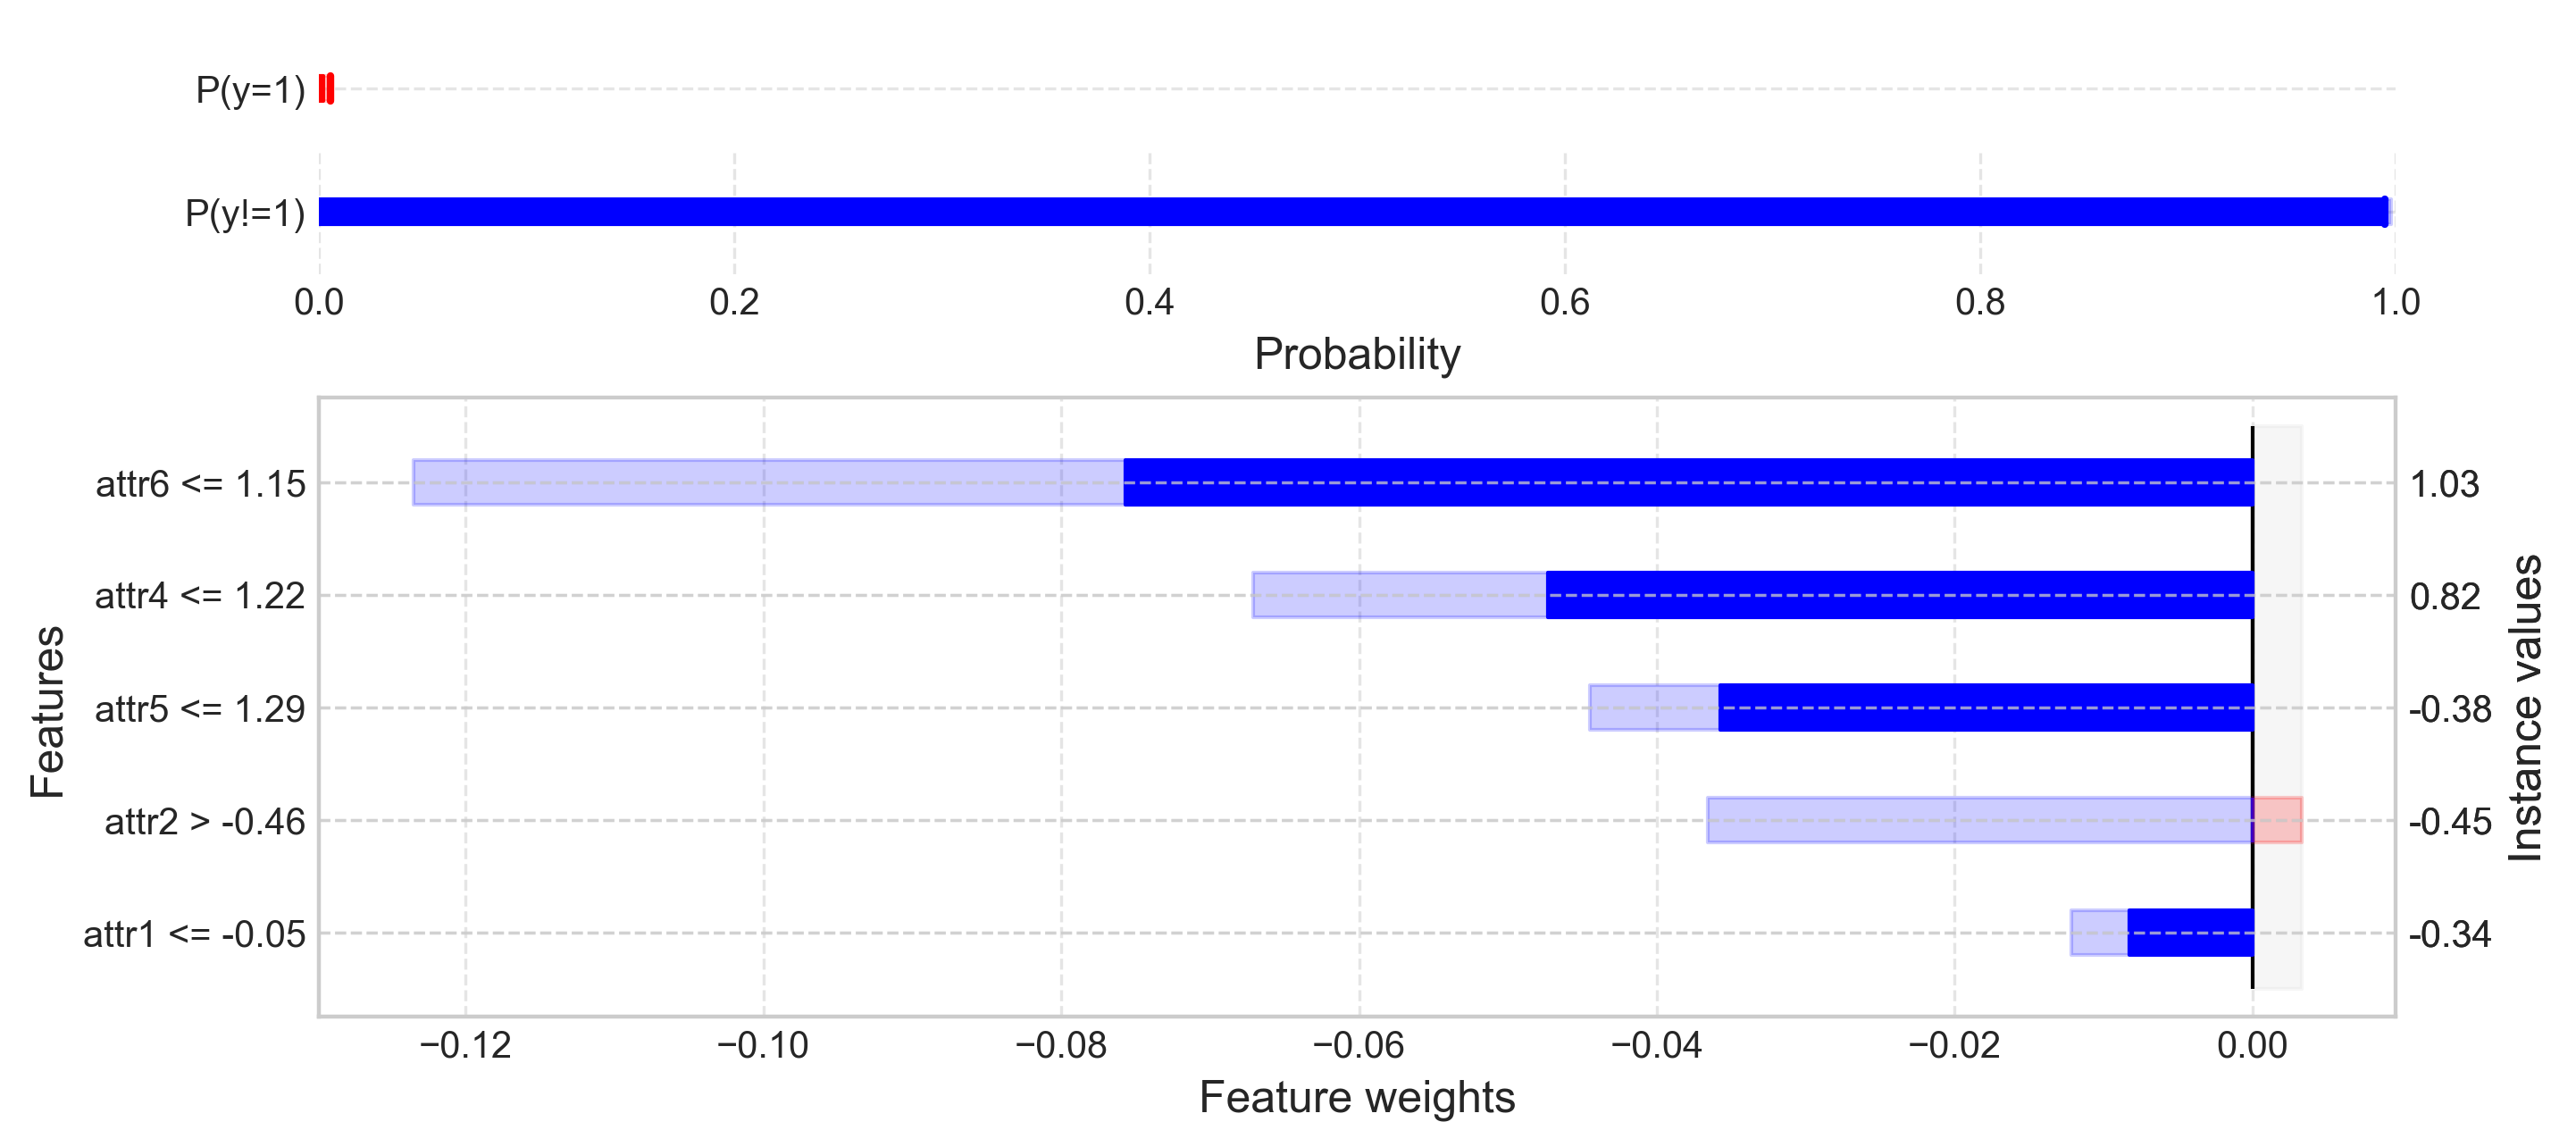

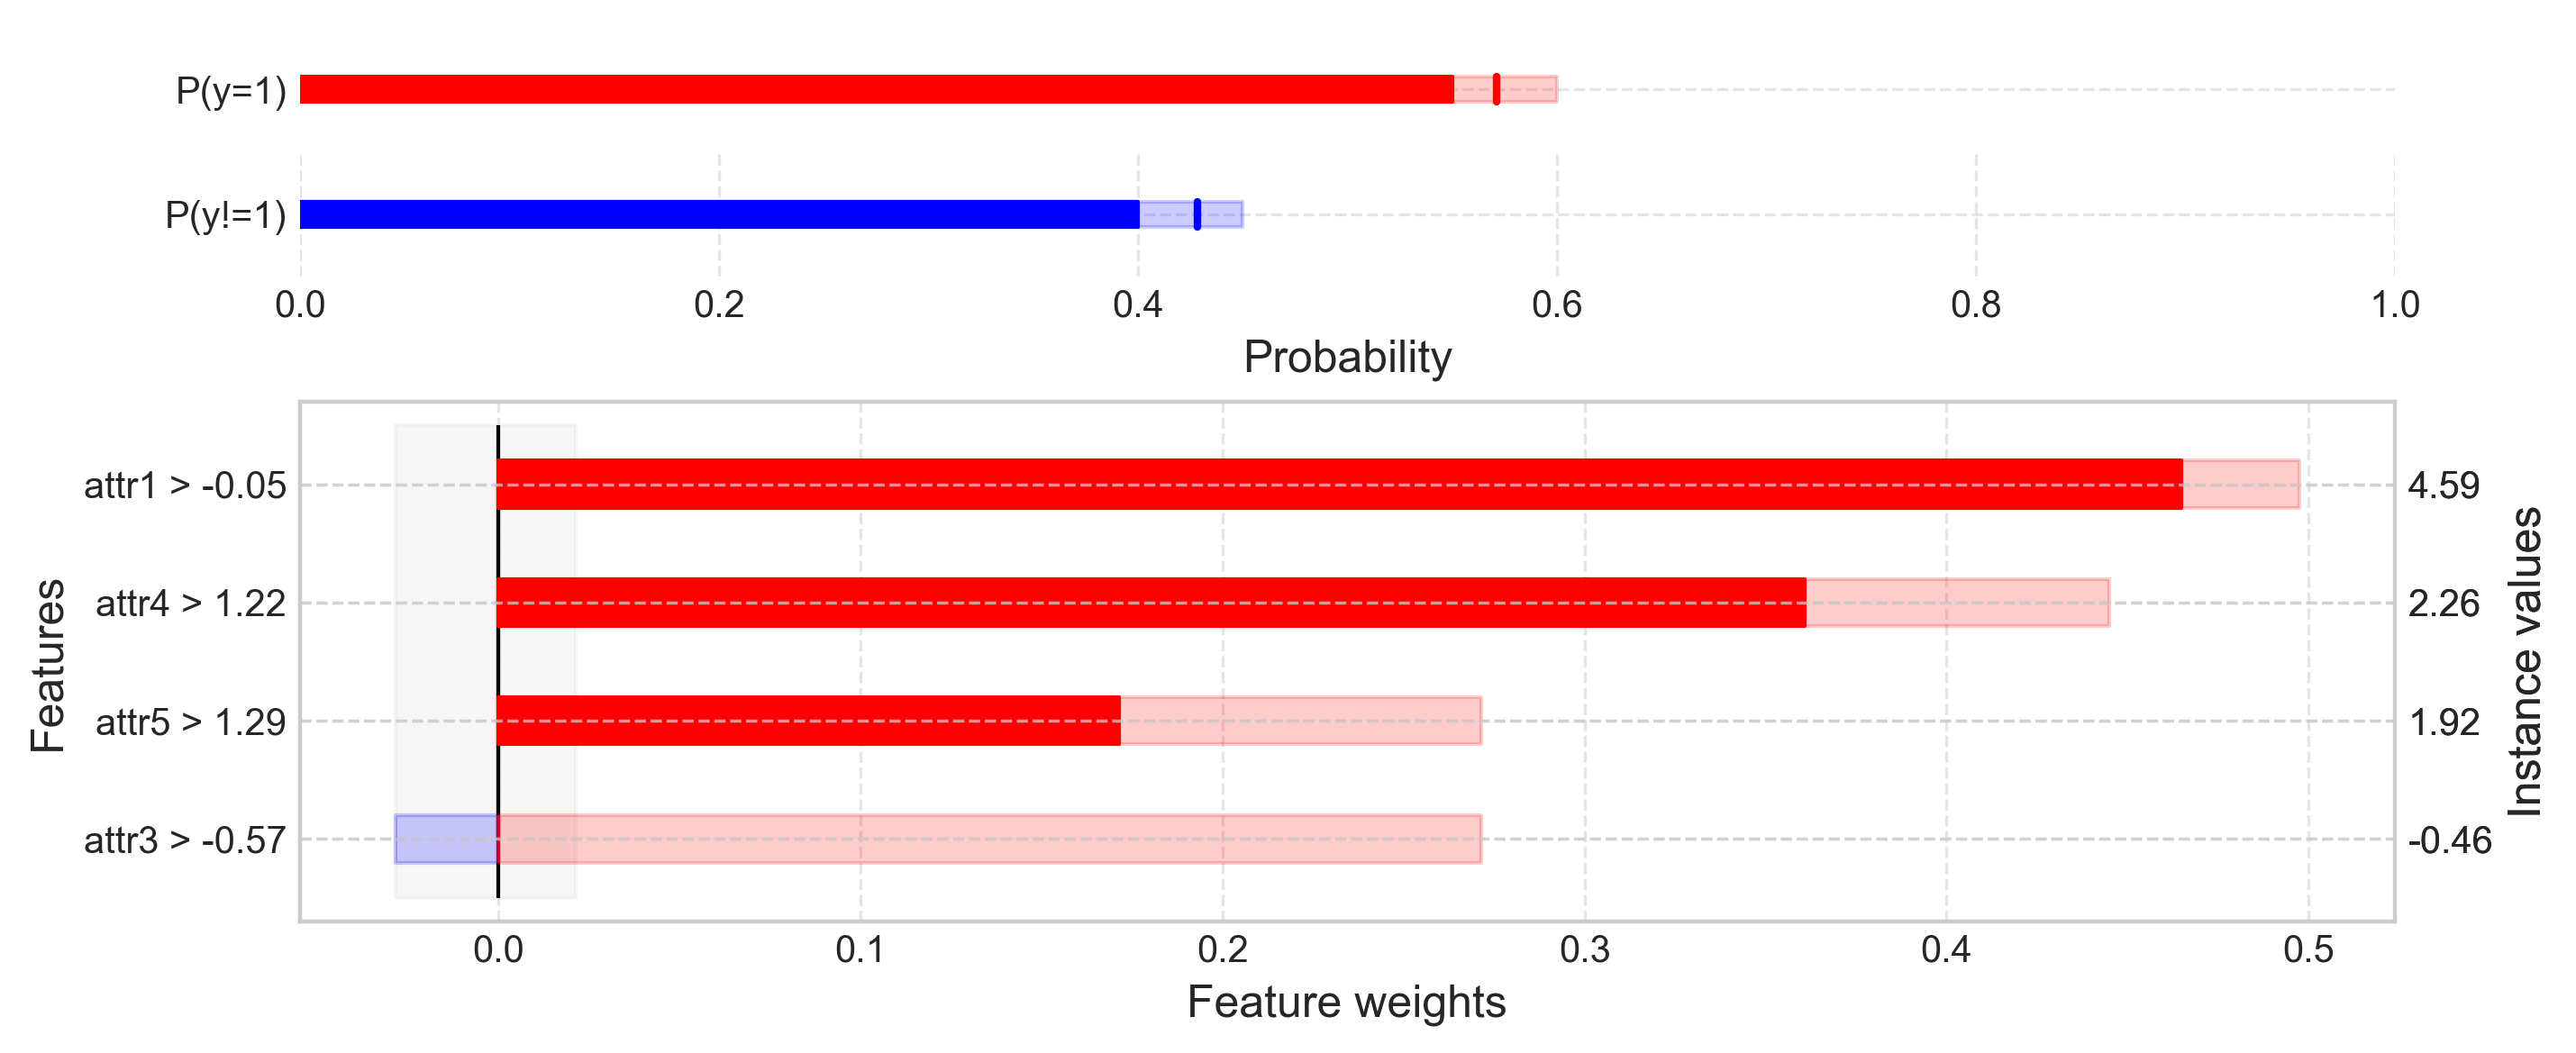

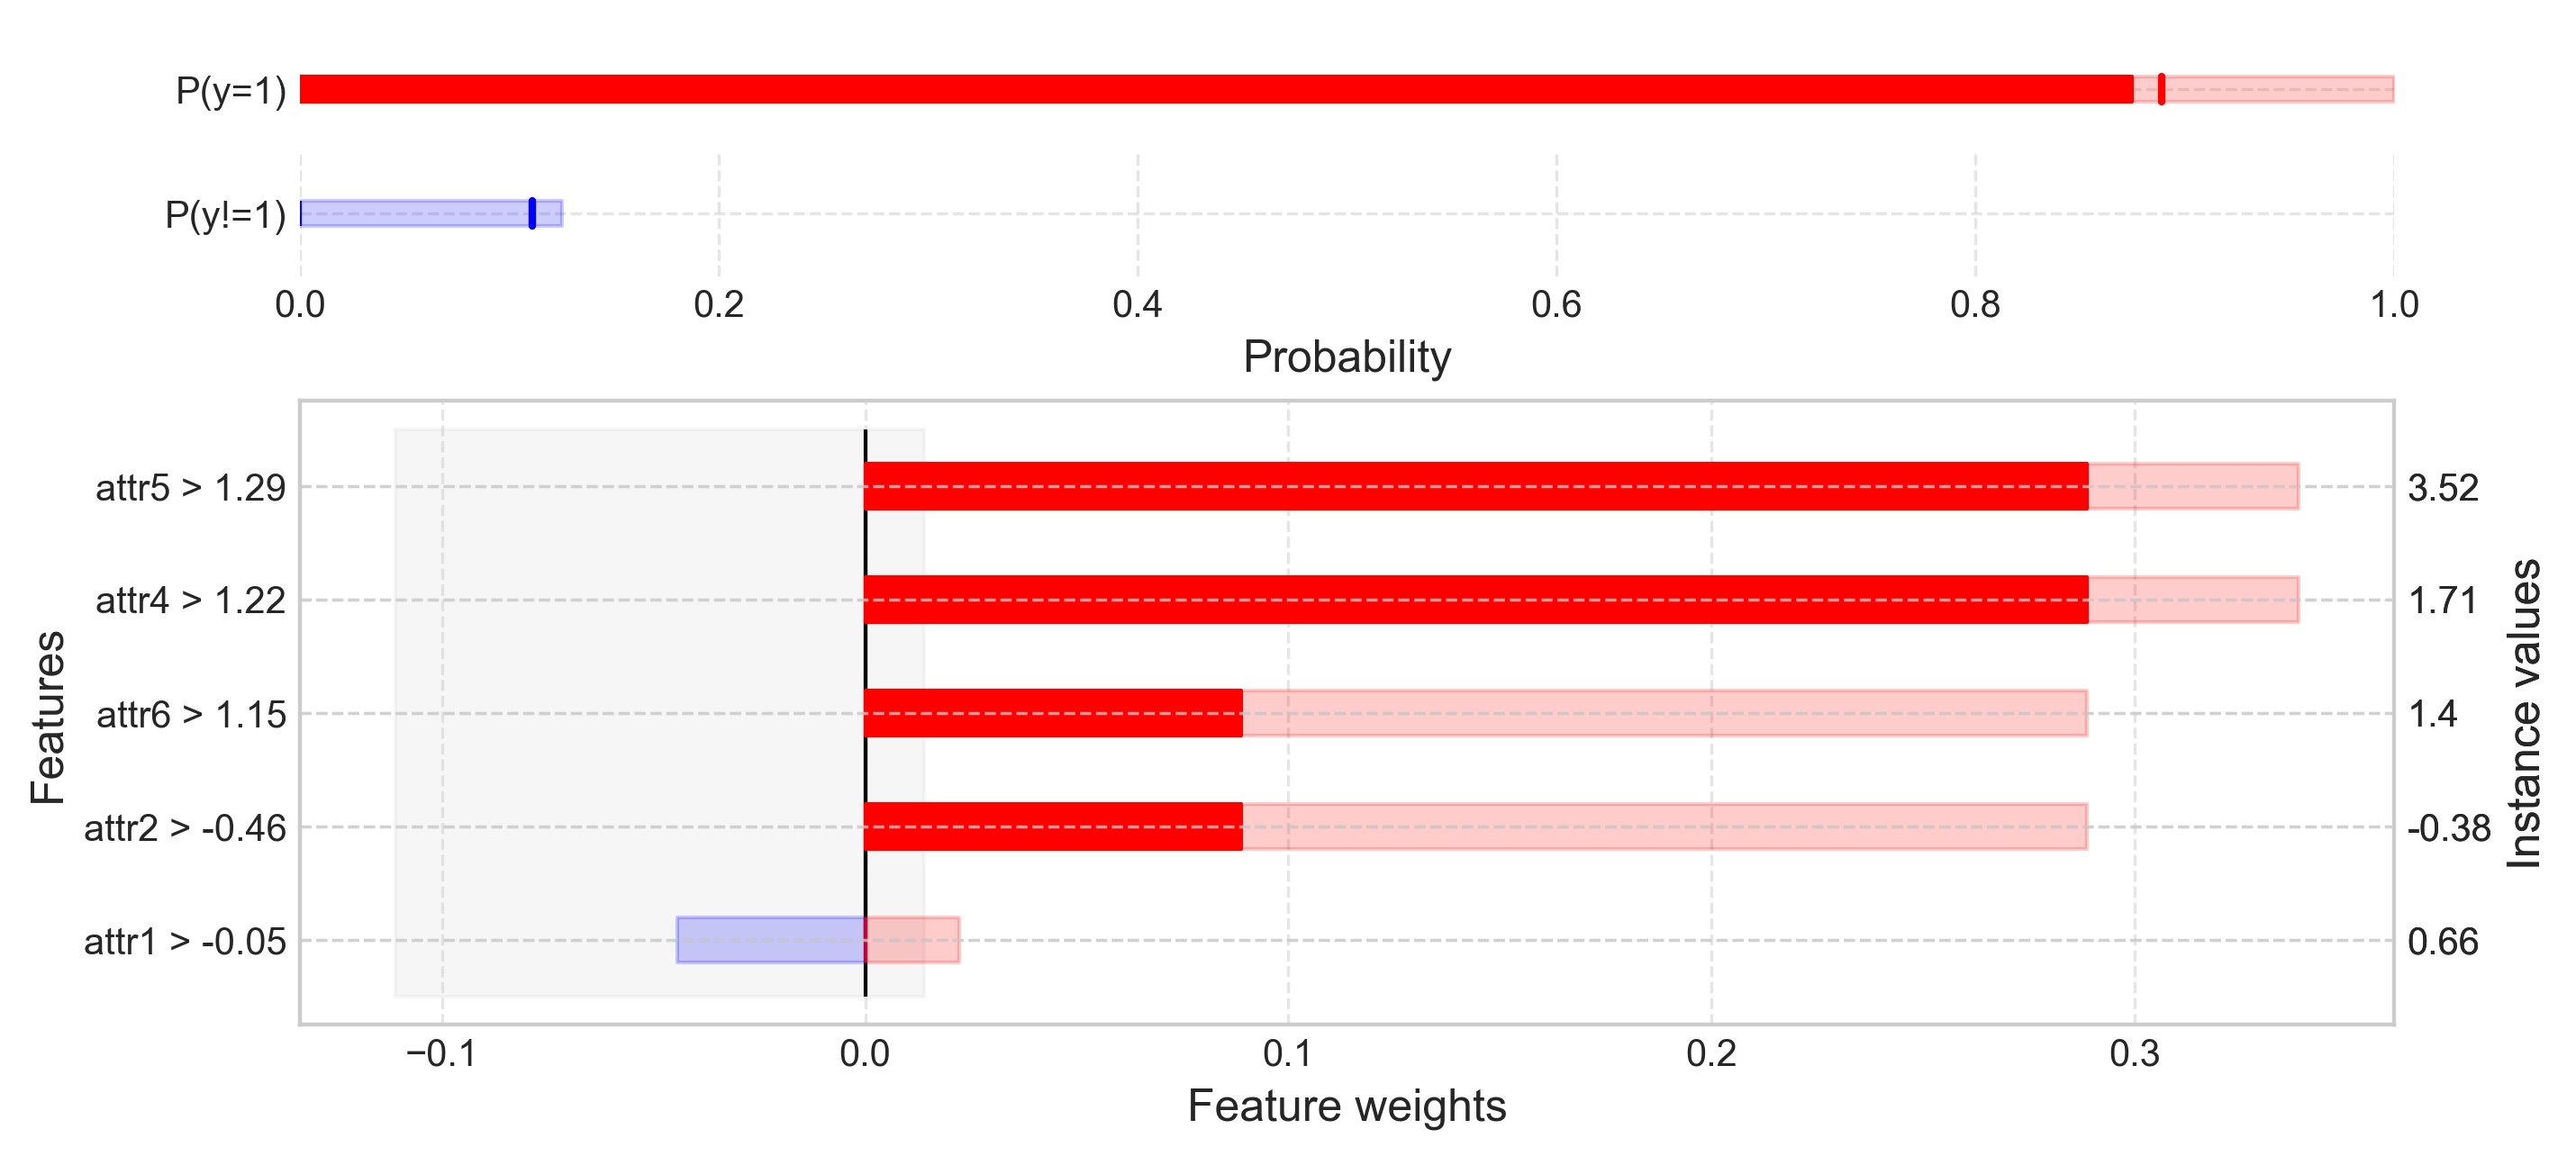

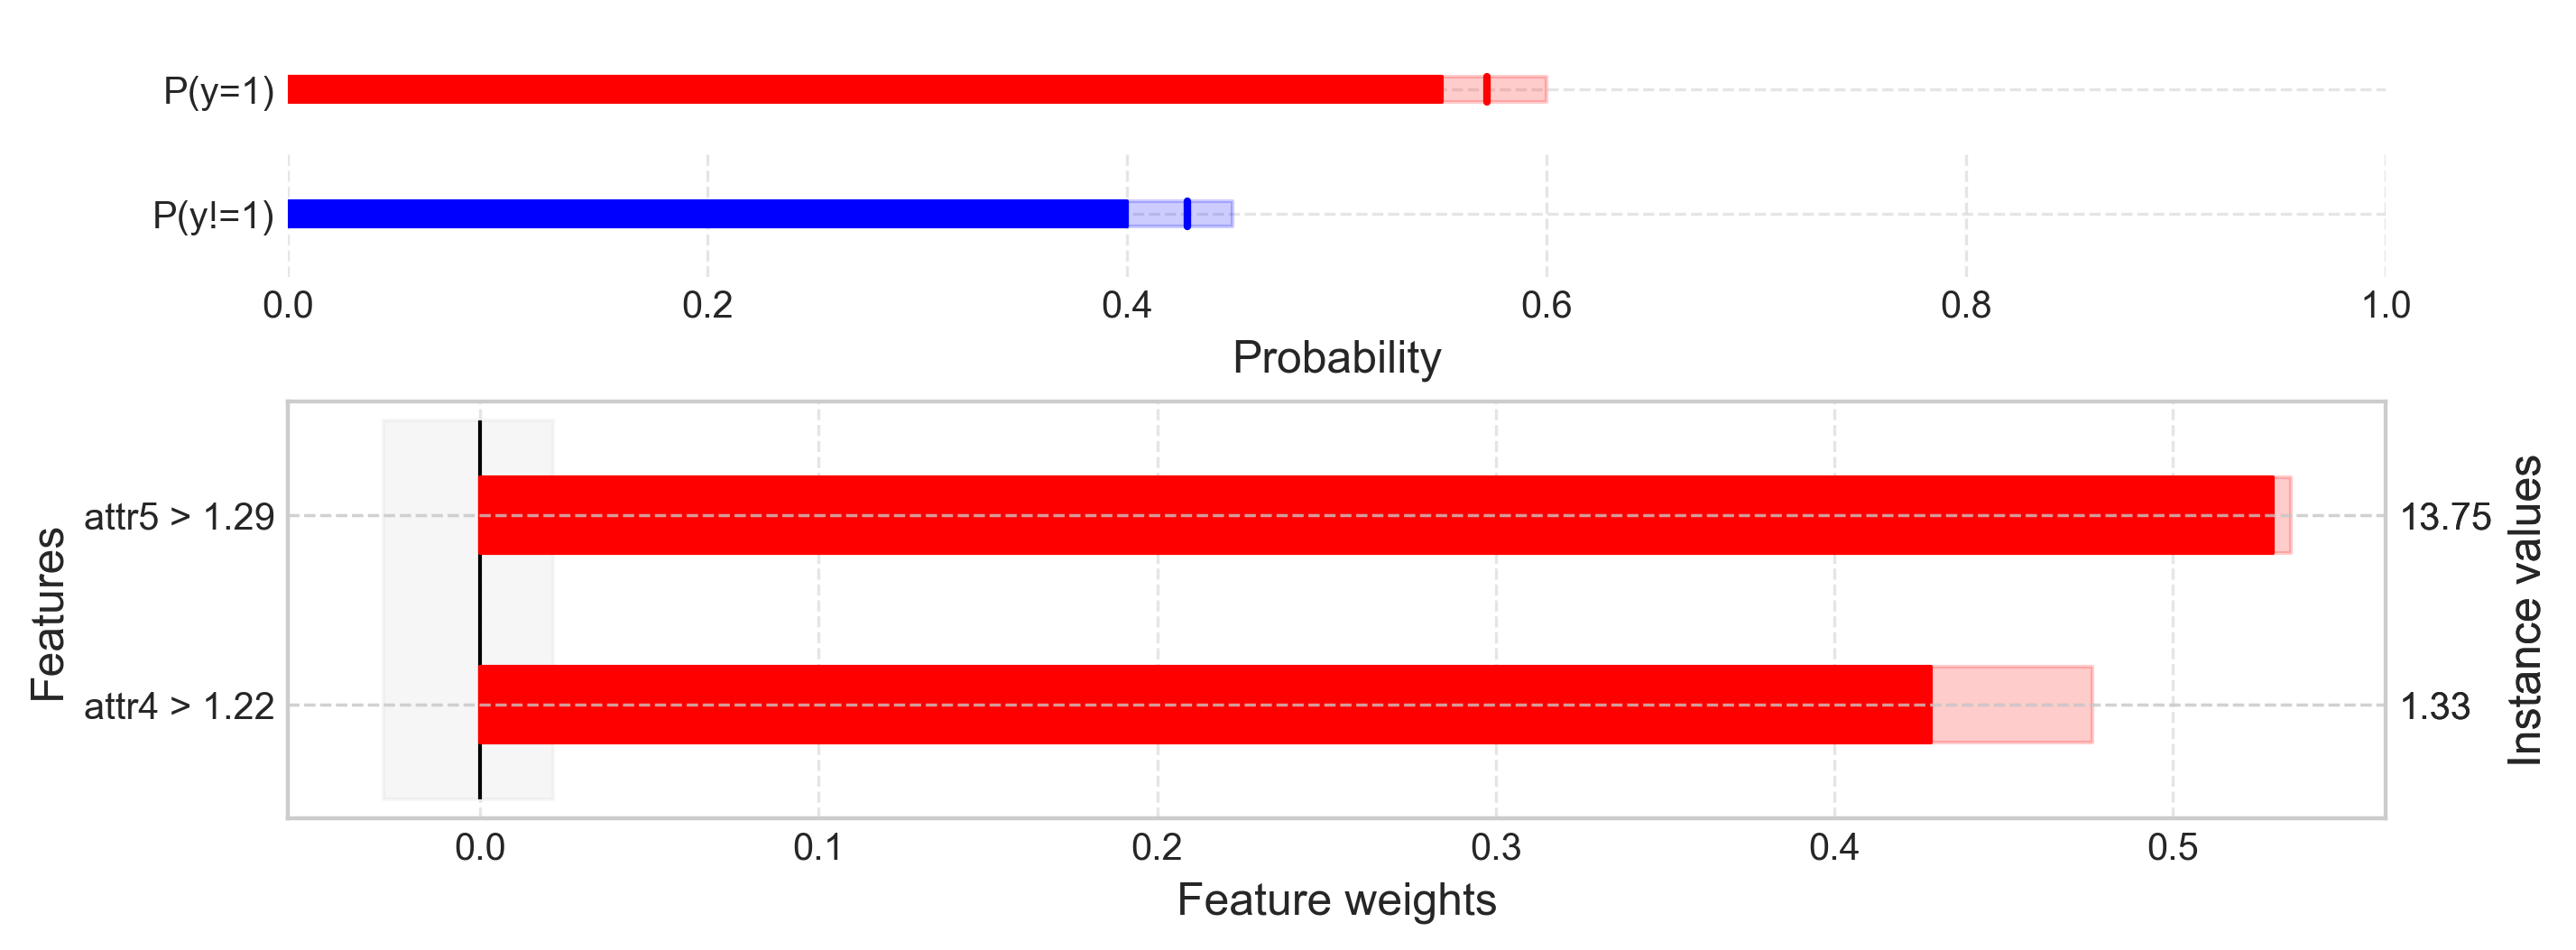

In [11]:
factual_explanations.plot(uncertainty=True)

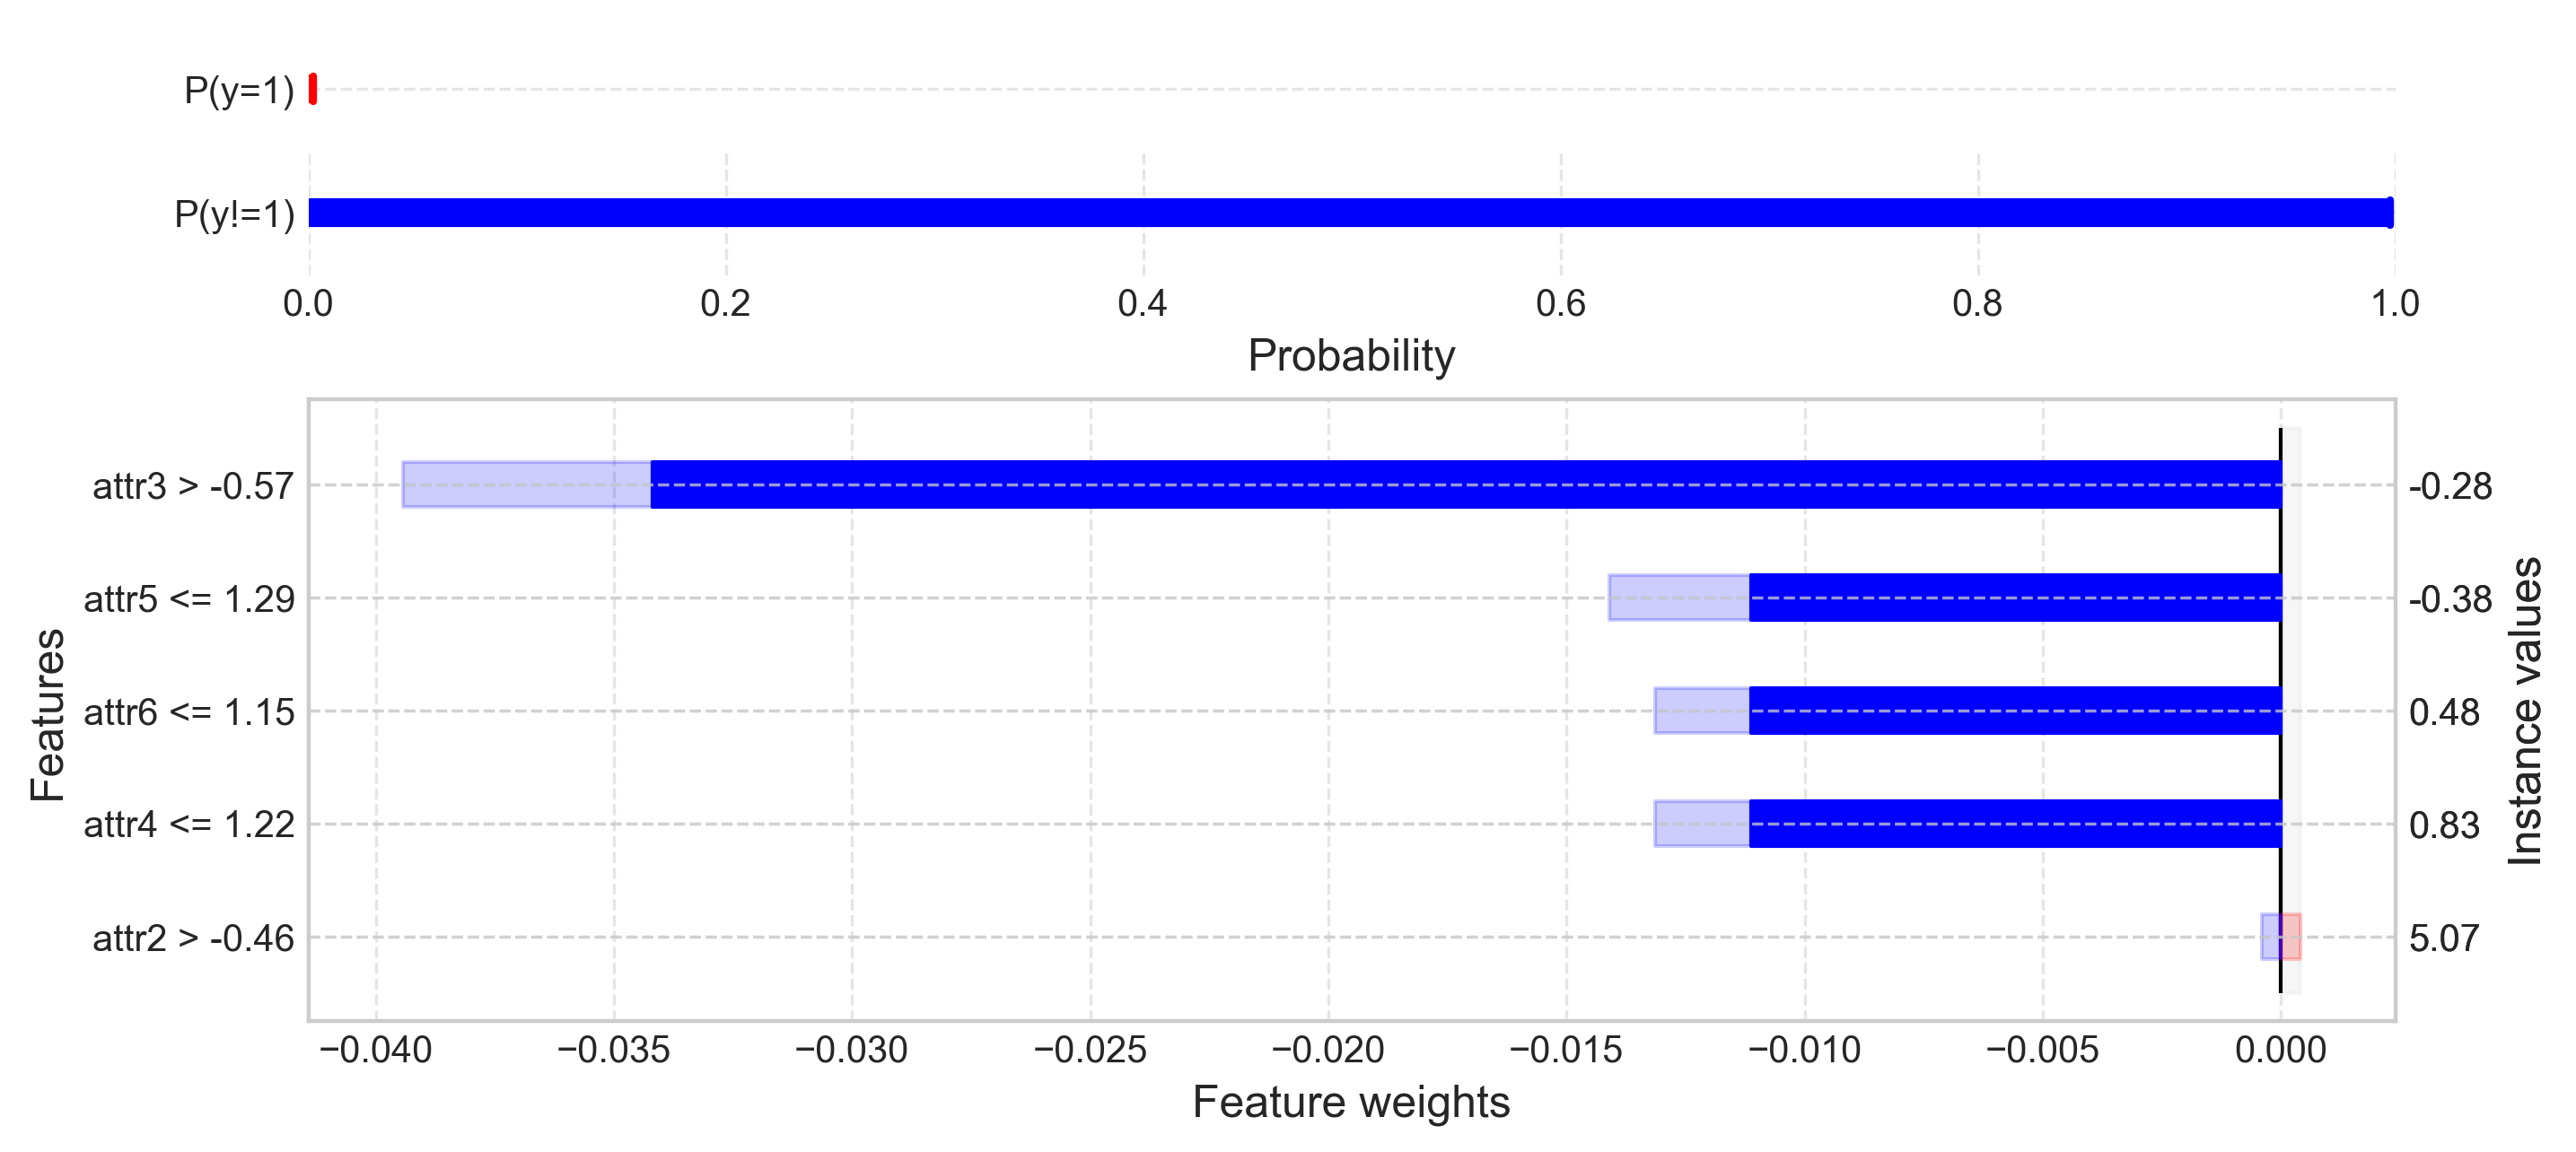

In [12]:
factual_explanations.plot(0, uncertainty=True)

You can also add and remove conjunctive rules.

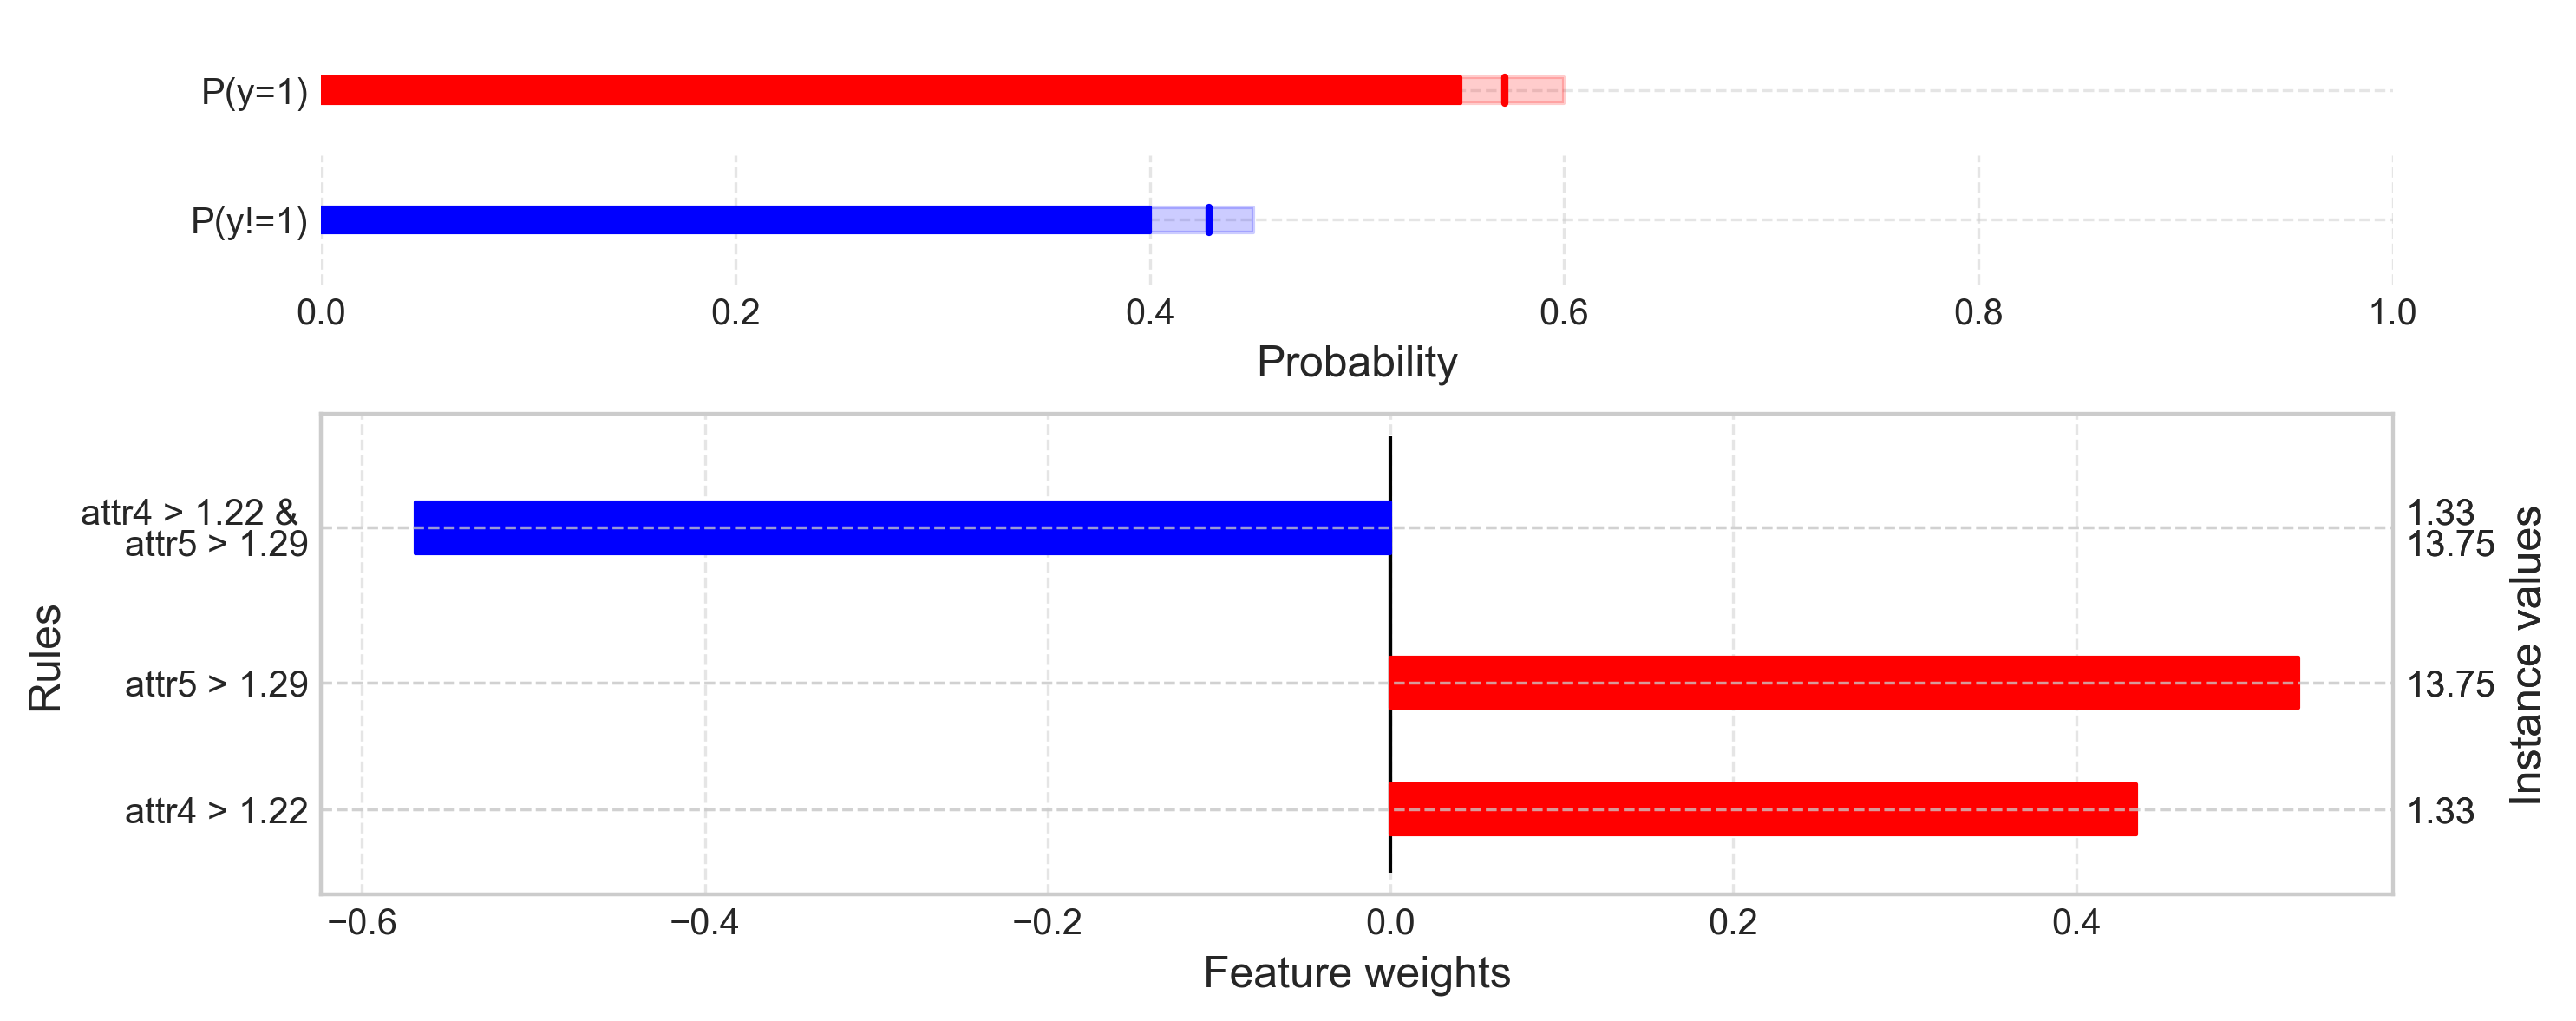

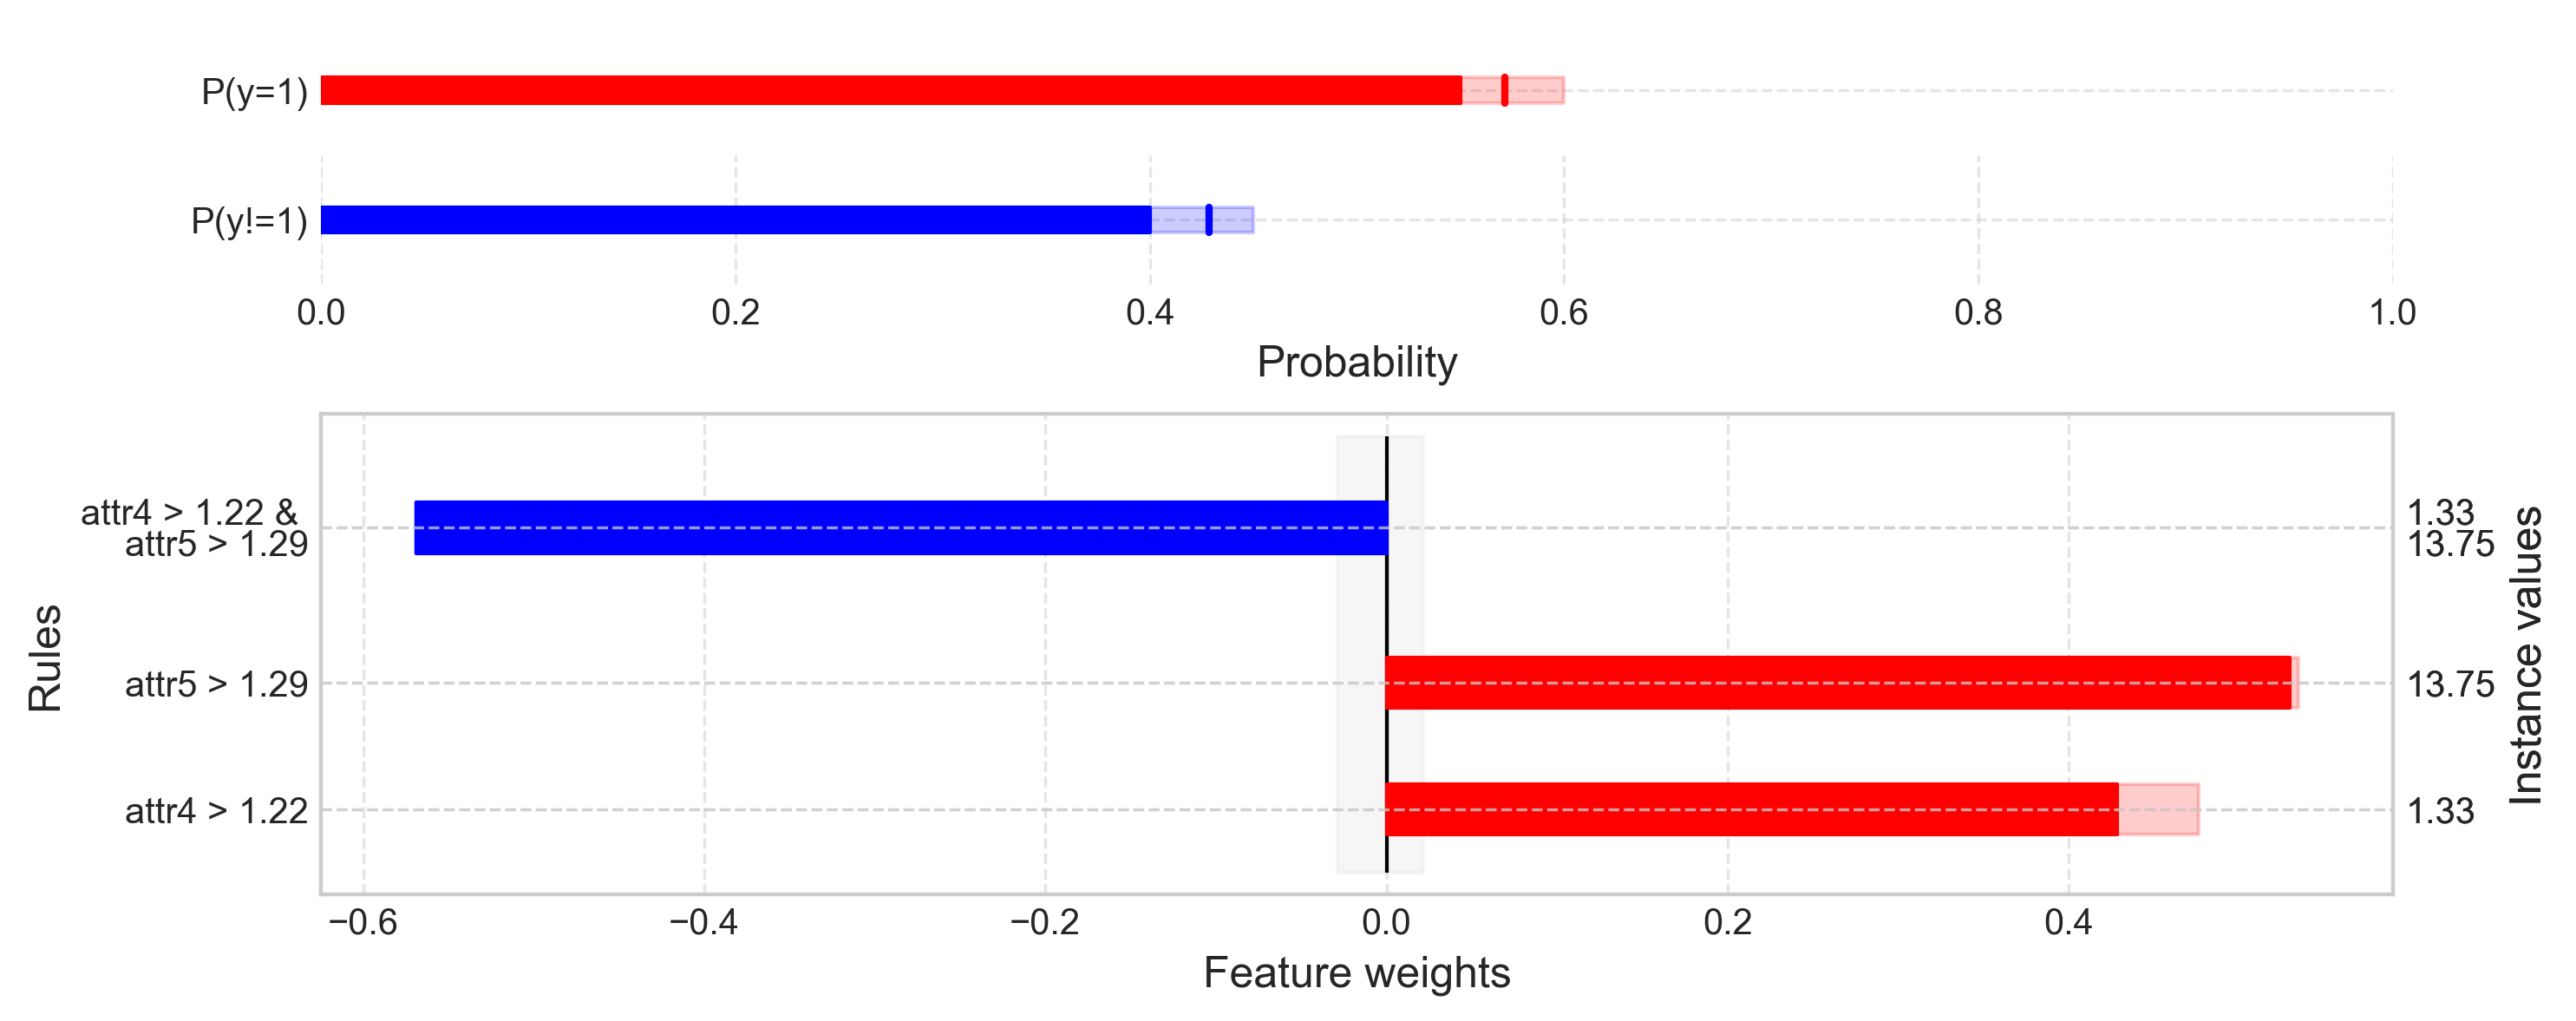

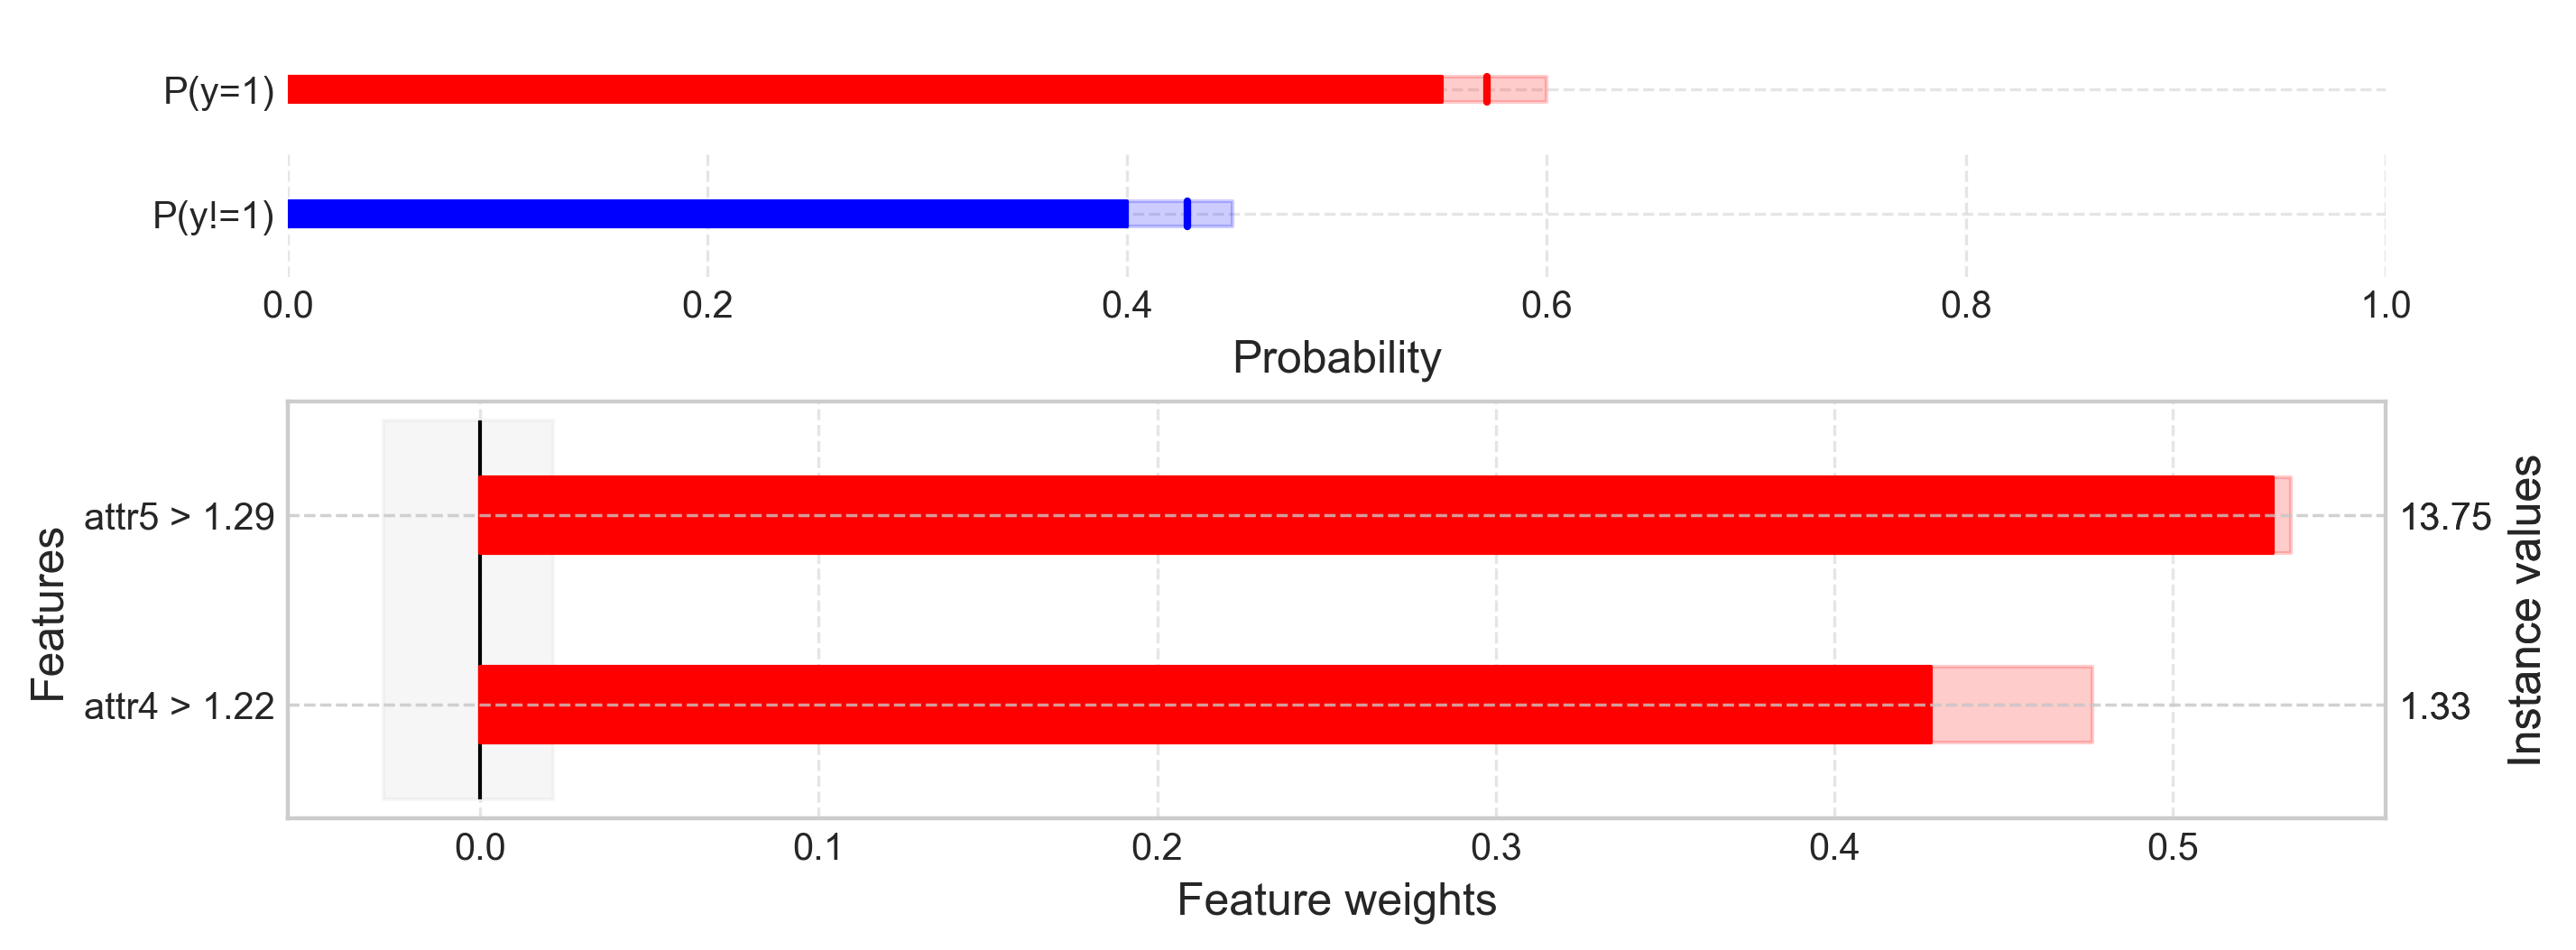

In [13]:
factual_explanations.add_conjunctions().plot(len(y_test) - 1)
factual_explanations.plot(len(y_test) - 1, uncertainty=True)
factual_explanations.remove_conjunctions().plot(len(y_test) - 1, uncertainty=True)

#### Alternative Explanations
An alternative to factual rules is to extract alternative rules. 
`explore_alternatives` can be called to get alternative rules with an appropriate discretizer automatically assigned. Note that the discretizer has changed. 

In [14]:
alternative_explanations = classifier.explore_alternatives(x_test)
display(classifier)

WrapCalibratedExplainer(learner=RandomForestClassifier(), fitted=True, calibrated=True, 
		explainer=CalibratedExplainer(mode=classification, discretizer=EntropyDiscretizer(), learner=RandomForestClassifier()))

Alternatives are also visualized using the `plot`. Plotting an individual alternative explanation is done using `plot`, submitting the index to plot. Adding or removing conjunctions is done as before. 

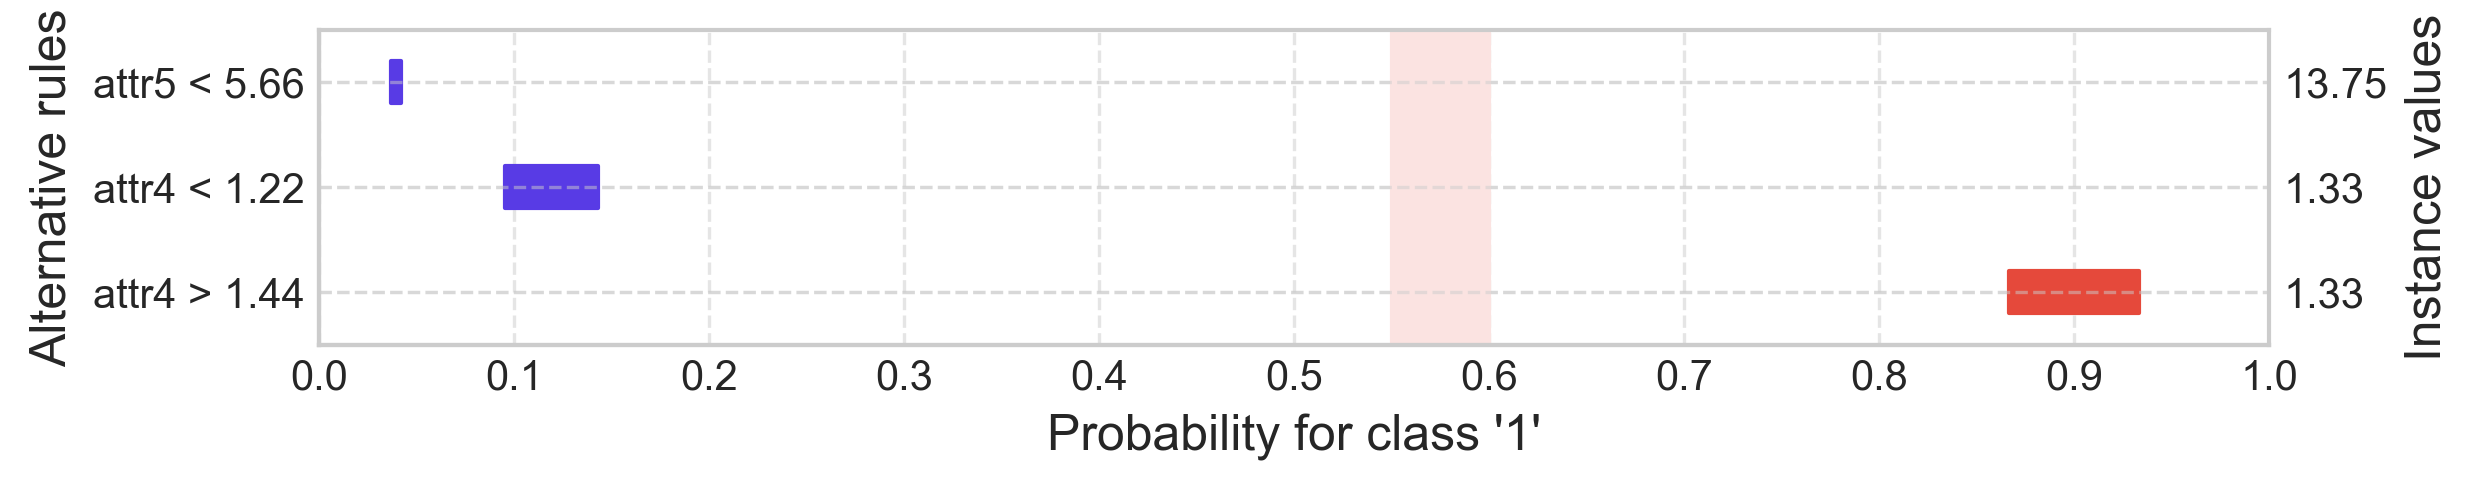

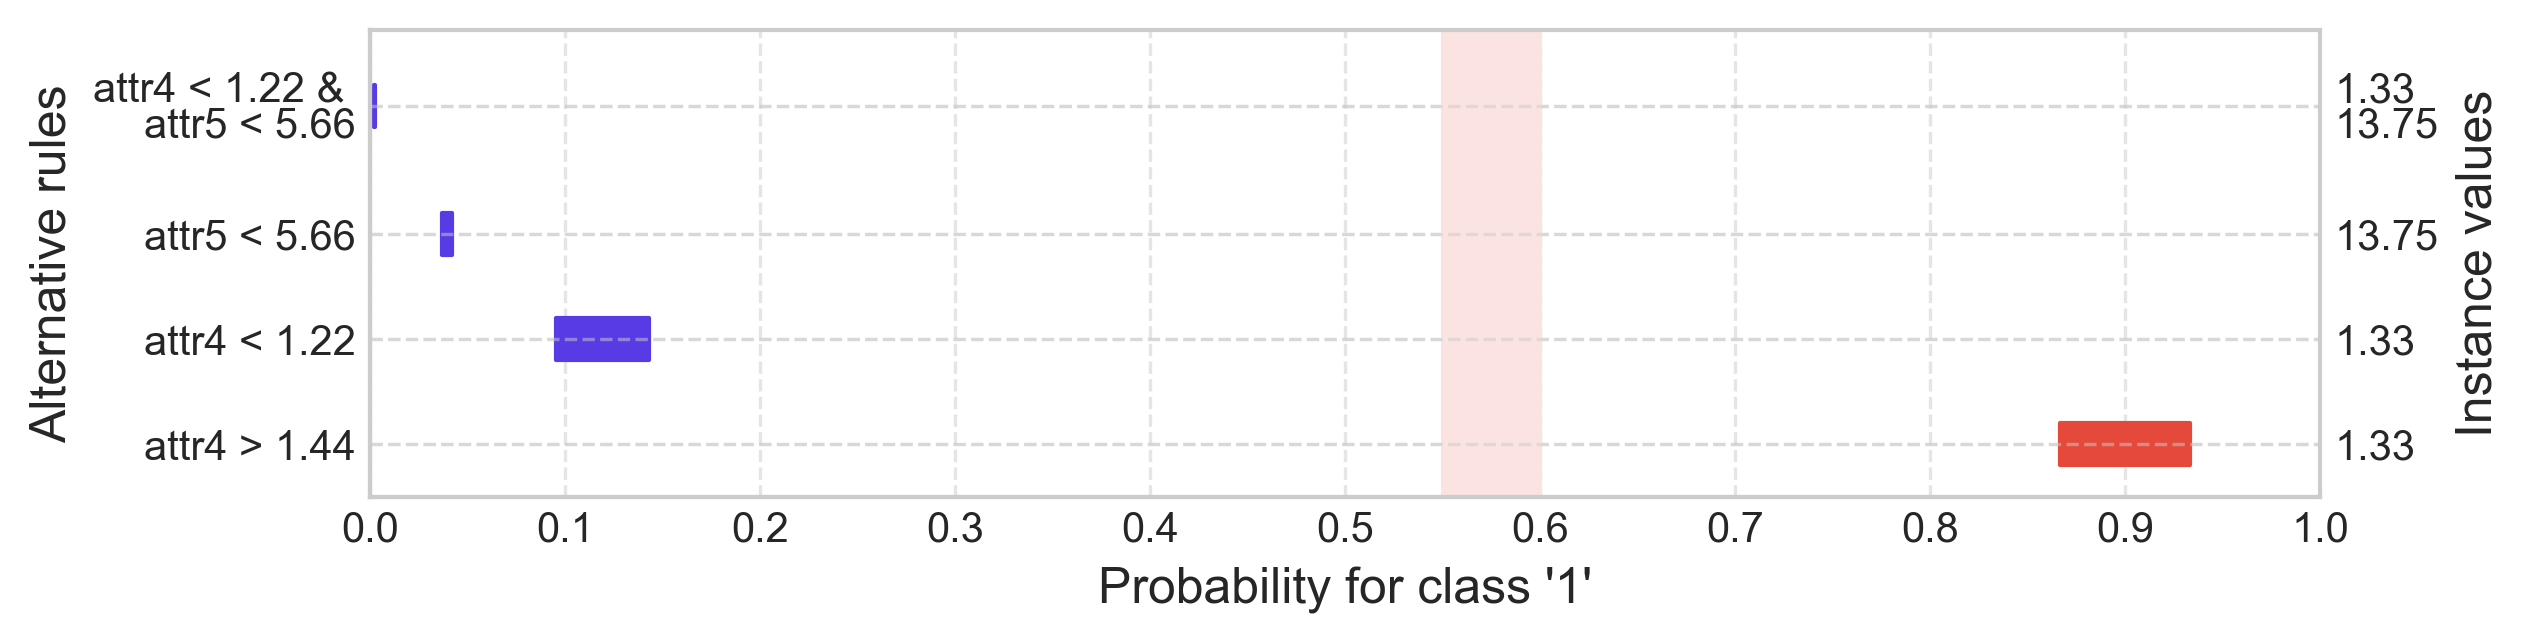

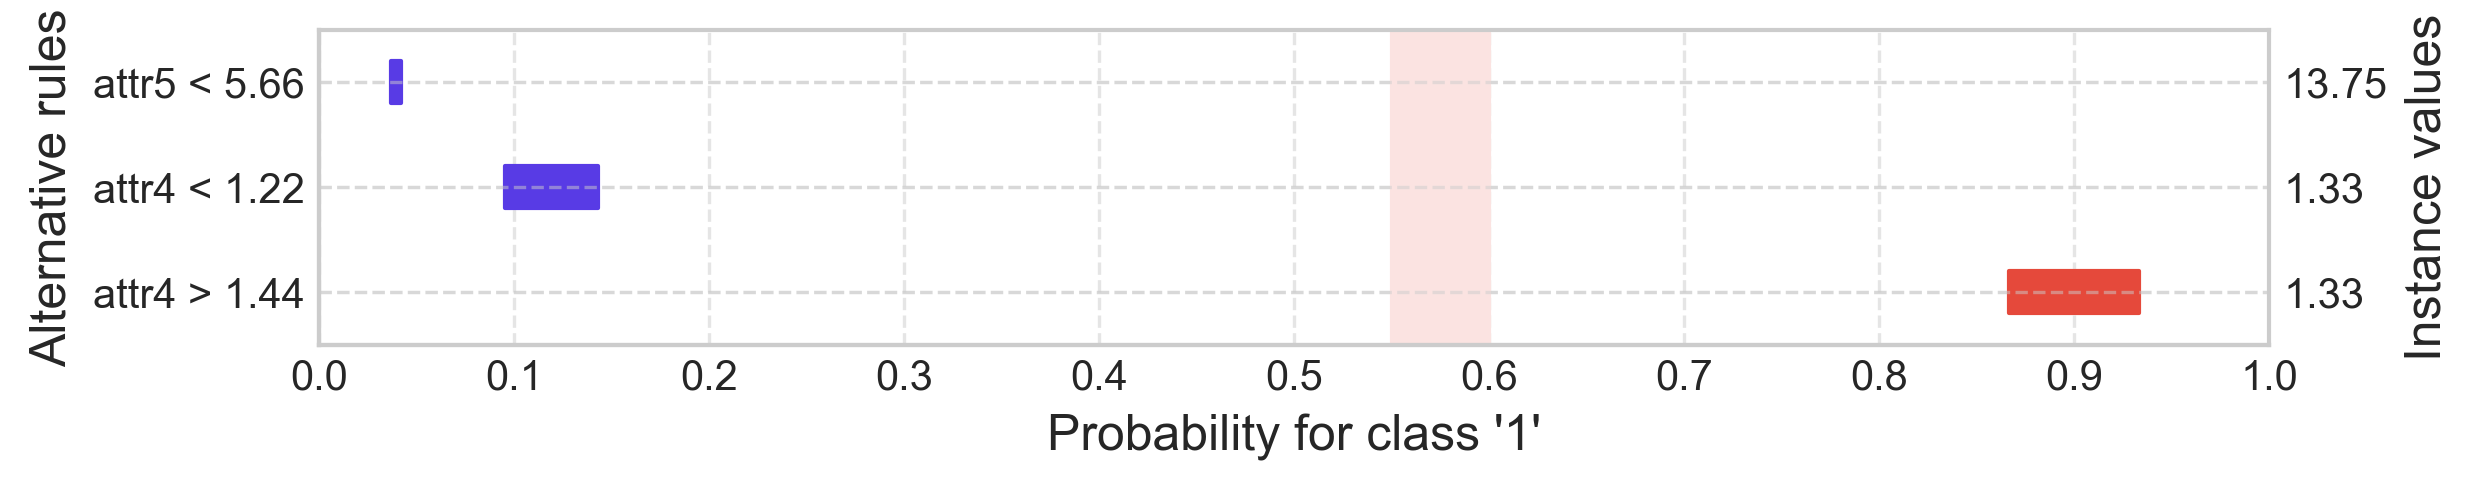

In [15]:
alternative_explanations.plot(len(y_test) - 1)
alternative_explanations.add_conjunctions().plot(len(y_test) - 1)

alternative_explanations.remove_conjunctions().plot(len(y_test) - 1)

`calibrated_explanations` supports multiclass which is demonstrated in [demo_multiclass](https://github.com/Moffran/calibrated_explanations/blob/main/notebooks/demo_multiclass.ipynb). That notebook also demonstrates how both feature names and target and categorical labels can be added to improve the interpretability. 